In [ ]:
"""
STN Validation Analyzer - Modular Functional Version
Compares iEEG and LCMV source-localized STN activity
"""

import numpy as np
import scipy.signal as signal
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Literal
import warnings
import logging
from IPython.display import display, Markdown, HTML
import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

# =============================================================================
# CONFIGURATION
# =============================================================================

BETA_BANDS = {
    'beta_13_16': (13, 16),
    'beta_16_19': (16, 19),
    'beta_19_22': (19, 22),
    'beta_22_25': (22, 25),
    'beta_25_28': (25, 28),
    'beta_28_31': (28, 31),
}

BAND_COLORS = {
    'beta_13_16': '#0000FF',
    'beta_16_19': '#4169E1',
    'beta_19_22': '#9370DB',
    'beta_22_25': '#BA55D3',
    'beta_25_28': '#FF69B4',
    'beta_28_31': '#FF1493',
}

BASELINE_NAMES = {'c': 'Eyes Closed', 'o': 'Eyes Open'}
VALID_SUBJECTS = ['sub-01', 'sub-05', 'sub-07', 'sub-10', 'sub-12', 'sub-14']
REF_FREQ_RANGE = (1, 3)  # Reference band for 0 dB alignment

ALL_SUBJECTS = ['sub-01', 'sub-05', 'sub-06', 'sub-07','sub-10', 'sub-11', 'sub-12', 'sub-14']
        


# =============================================================================
# DATA LOADING
# =============================================================================

def load_consolidated_data(ieeg_path: Path, lcmv_path: Path) -> Tuple[dict, dict]:
    """Load iEEG and LCMV data from consolidated npz files"""
    for path, name in [(ieeg_path, 'iEEG'), (lcmv_path, 'LCMV')]:
        if not path.exists():
            raise FileNotFoundError(f"{name} data not found: {path}")
    
    logger.info("Loading iEEG and LCMV data...")
    
    ieeg_file = np.load(ieeg_path, allow_pickle=True)
    lcmv_file = np.load(lcmv_path, allow_pickle=True)
    
    ieeg_data = ieeg_file['data'].item()
    lcmv_data = lcmv_file['data'].item()
    
    logger.info(f"✓ Loaded {len(ieeg_data)} iEEG subjects, {len(lcmv_data)} LCMV subjects")
    
    return ieeg_data, lcmv_data


def get_subject_data(ieeg_data: dict, lcmv_data: dict, subject: str, 
                     analysis_type: Literal['atlas', 'voxel']) -> Optional[dict]:
    """
    Extract and prepare data for a single subject.
    Returns None if subject missing required data.
    """
    if subject not in ieeg_data or subject not in lcmv_data:
        return None
    
    subj_ieeg = ieeg_data[subject]
    subj_lcmv = lcmv_data[subject]
    
    ieeg_sfreq = subj_ieeg.get('meta', {}).get('sfreq', 250.0)
    lcmv_sfreq = subj_lcmv.get('meta', {}).get('sfreq', 500.0)
    
    # Define ROI patterns based on analysis type
    if analysis_type == 'atlas':
        roi_patterns = {'L_STN': ['STN_atlas'], 'R_STN': ['STN_atlas']}
    else:  # voxel
        roi_patterns = {'L_STN': ['L_STN_voxel'], 'R_STN': ['R_STN_voxel']}
    
    result = {}
    
    for region in ['L_STN', 'R_STN']:
        # Get iEEG data (direct access - no searching needed)
        ieeg_runs = {}
        for run in ['c', 'o', 'l', 'r']:
            if run in subj_ieeg and region in subj_ieeg[run]:
                ts = subj_ieeg[run][region].copy()
                if ts.ndim > 1:
                    ts = ts.flatten()
                ieeg_runs[run] = align_spectrum_to_zero(ts, ieeg_sfreq)
        
        # Get LCMV data
        lcmv_runs = {}
        for run in ['c', 'o', 'l', 'r']:
            if run in subj_lcmv:
                for pattern in roi_patterns[region]:
                    if pattern in subj_lcmv[run]:
                        ts = subj_lcmv[run][pattern].copy()
                        if ts.ndim > 1:
                            ts = ts.flatten()
                        lcmv_runs[run] = align_spectrum_to_zero(ts, lcmv_sfreq)
                        break
        
        # Only include if we have both iEEG and LCMV data for at least some runs
        if ieeg_runs and lcmv_runs:
            result[region] = {
                'ieeg': ieeg_runs,
                'lcmv': lcmv_runs,
                'ieeg_sfreq': ieeg_sfreq,
                'lcmv_sfreq': lcmv_sfreq
            }
    
    return result if result else None


def collect_all_data(ieeg_data: dict, lcmv_data: dict, 
                     analysis_type: Literal['atlas', 'voxel']) -> dict:
    """Collect data for all valid subjects"""
    collected = {}
    
    for subj in VALID_SUBJECTS:
        subj_data = get_subject_data(ieeg_data, lcmv_data, subj, analysis_type)
        if subj_data:
            collected[subj] = subj_data
            logger.info(f"✓ Added {subj}: {list(subj_data.keys())}")
    
    logger.info(f"\nCollected data for {len(collected)} subjects")
    return collected

# =============================================================================
# SIGNAL PROCESSING
# =============================================================================

def highpass_filter(ts: np.ndarray, sfreq: float, cutoff: float = 0.5) -> np.ndarray:
    """Apply high-pass filter to remove slow drifts"""
    nyq = sfreq * 0.5
    b, a = signal.butter(4, cutoff / nyq, btype='high')
    return signal.filtfilt(b, a, ts)


def get_spectrum(time_series: np.ndarray, sfreq: float) -> Tuple[np.ndarray, np.ndarray]:
    """Compute power spectrum using Welch's method"""
    ts = np.real(time_series).astype(np.float64)
    
    nperseg = int(2.0 * sfreq)
    if len(ts) < nperseg:
        logger.warning(f"Time series too short: {len(ts)} < {nperseg}")
        return None, None
    
    filtered = highpass_filter(ts, sfreq)
    
    freqs, psd = signal.welch(
        filtered, fs=sfreq, window='hann',
        nperseg=nperseg, noverlap=nperseg // 2,
        nfft=nperseg, scaling='density'
    )
    
    return freqs, psd


def get_band_power(time_series: np.ndarray, sfreq: float, 
                   band: Tuple[float, float]) -> float:
    """Get integrated power in a frequency band (linear scale)"""
    freqs, psd = get_spectrum(time_series, sfreq)
    if freqs is None or psd is None:
        return np.nan
    
    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    if not np.any(band_mask):
        return np.nan
    
    return float(trapezoid(psd[band_mask], freqs[band_mask]))


def align_spectrum_to_zero(time_series: np.ndarray, sfreq: float) -> np.ndarray:
    """
    Scale time series so that low-frequency power is 1 (0 dB after log transform)
    """
    freqs, psd = get_spectrum(time_series, sfreq)
    if freqs is None or psd is None:
        return time_series
    
    ref_mask = (freqs >= REF_FREQ_RANGE[0]) & (freqs <= REF_FREQ_RANGE[1])
    if not np.any(ref_mask):
        ref_mask = np.zeros_like(freqs, dtype=bool)
        ref_mask[:min(5, len(freqs))] = True
    
    ref_power = np.mean(psd[ref_mask])
    
    if ref_power > 0:
        scale_factor = 1.0 / ref_power
        return time_series * np.sqrt(scale_factor)
    
    return time_series


def get_band_power_db(time_series: np.ndarray, sfreq: float, 
                      band: Tuple[float, float]) -> float:
    """Get band power in dB"""
    power = get_band_power(time_series, sfreq, band)
    return 10.0 * np.log10(power + 1e-30) if not np.isnan(power) else np.nan

# =============================================================================
# ANALYSIS
# =============================================================================

def compute_power_changes(subject_data: dict) -> dict:
    """
    Compute power changes for all bands and conditions.
    Returns nested dict with results for each region and band.
    """
    results = {}
    
    for region, data in subject_data.items():
        region_results = {}
        
        for band_name, band_limits in BETA_BANDS.items():
            # Get powers in dB
            powers = {}
            for modality in ['ieeg', 'lcmv']:
                sfreq_key = f'{modality}_sfreq'
                for run in ['c', 'o', 'l', 'r']:
                    if run in data[modality]:
                        key = f'{modality}_{run}'
                        powers[key] = get_band_power_db(
                            data[modality][run], data[sfreq_key], band_limits)
                    else:
                        powers[f'{modality}_{run}'] = np.nan
            
            # Compute changes relative to baselines
            changes = {
                'left_hand': {
                    'ieeg_c': powers['ieeg_l'] - powers['ieeg_c'] if not np.isnan(powers['ieeg_l']) and not np.isnan(powers['ieeg_c']) else np.nan,
                    'lcmv_c': powers['lcmv_l'] - powers['lcmv_c'] if not np.isnan(powers['lcmv_l']) and not np.isnan(powers['lcmv_c']) else np.nan,
                    'ieeg_o': powers['ieeg_l'] - powers['ieeg_o'] if not np.isnan(powers['ieeg_l']) and not np.isnan(powers['ieeg_o']) else np.nan,
                    'lcmv_o': powers['lcmv_l'] - powers['lcmv_o'] if not np.isnan(powers['lcmv_l']) and not np.isnan(powers['lcmv_o']) else np.nan,
                },
                'right_hand': {
                    'ieeg_c': powers['ieeg_r'] - powers['ieeg_c'] if not np.isnan(powers['ieeg_r']) and not np.isnan(powers['ieeg_c']) else np.nan,
                    'lcmv_c': powers['lcmv_r'] - powers['lcmv_c'] if not np.isnan(powers['lcmv_r']) and not np.isnan(powers['lcmv_c']) else np.nan,
                    'ieeg_o': powers['ieeg_r'] - powers['ieeg_o'] if not np.isnan(powers['ieeg_r']) and not np.isnan(powers['ieeg_o']) else np.nan,
                    'lcmv_o': powers['lcmv_r'] - powers['lcmv_o'] if not np.isnan(powers['lcmv_r']) and not np.isnan(powers['lcmv_o']) else np.nan,
                }
            }
            
            region_results[band_name] = changes
        
        results[region] = region_results
    
    return results


def get_match_results(computed_results: dict) -> Tuple[dict, dict]:
    """
    Convert computed power changes to match/suppression results.
    Returns (ec_results, eo_results) dictionaries.
    """
    ec_results = {'L_STN': [], 'R_STN': []}
    eo_results = {'L_STN': [], 'R_STN': []}
    
    for subject, regions in computed_results.items():
        for region, bands in regions.items():
            for band_name, changes in bands.items():
                # EC matches
                lh_match_c = not np.isnan(changes['left_hand']['ieeg_c']) and not np.isnan(changes['left_hand']['lcmv_c']) and changes['left_hand']['ieeg_c'] * changes['left_hand']['lcmv_c'] > 0
                rh_match_c = not np.isnan(changes['right_hand']['ieeg_c']) and not np.isnan(changes['right_hand']['lcmv_c']) and changes['right_hand']['ieeg_c'] * changes['right_hand']['lcmv_c'] > 0
                lh_suppress_c = not np.isnan(changes['left_hand']['ieeg_c']) and not np.isnan(changes['left_hand']['lcmv_c']) and changes['left_hand']['ieeg_c'] < 0 and changes['left_hand']['lcmv_c'] < 0
                rh_suppress_c = not np.isnan(changes['right_hand']['ieeg_c']) and not np.isnan(changes['right_hand']['lcmv_c']) and changes['right_hand']['ieeg_c'] < 0 and changes['right_hand']['lcmv_c'] < 0
                
                ec_results[region].append({
                    'subject': subject,
                    'band': band_name,
                    'lh_match': lh_match_c,
                    'rh_match': rh_match_c,
                    'lh_suppress': lh_suppress_c,
                    'rh_suppress': rh_suppress_c
                })
                
                # EO matches
                lh_match_o = not np.isnan(changes['left_hand']['ieeg_o']) and not np.isnan(changes['left_hand']['lcmv_o']) and changes['left_hand']['ieeg_o'] * changes['left_hand']['lcmv_o'] > 0
                rh_match_o = not np.isnan(changes['right_hand']['ieeg_o']) and not np.isnan(changes['right_hand']['lcmv_o']) and changes['right_hand']['ieeg_o'] * changes['right_hand']['lcmv_o'] > 0
                lh_suppress_o = not np.isnan(changes['left_hand']['ieeg_o']) and not np.isnan(changes['left_hand']['lcmv_o']) and changes['left_hand']['ieeg_o'] < 0 and changes['left_hand']['lcmv_o'] < 0
                rh_suppress_o = not np.isnan(changes['right_hand']['ieeg_o']) and not np.isnan(changes['right_hand']['lcmv_o']) and changes['right_hand']['ieeg_o'] < 0 and changes['right_hand']['lcmv_o'] < 0
                
                eo_results[region].append({
                    'subject': subject,
                    'band': band_name,
                    'lh_match': lh_match_o,
                    'rh_match': rh_match_o,
                    'lh_suppress': lh_suppress_o,
                    'rh_suppress': rh_suppress_o
                })
    
    return ec_results, eo_results

# =============================================================================
# PLOTTING FUNCTIONS
# =============================================================================

def plot_power_spectra(subject_data: dict, subject: str, region: str,
                       save_path: Optional[Path] = None, show: bool = True):
    """Plot power spectra for all conditions"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    conditions = [('c', 'Eyes Closed'), ('o', 'Eyes Open'),
                  ('l', 'Left Hand'), ('r', 'Right Hand')]
    colors = {'c': 'blue', 'o': 'cyan', 'l': 'red', 'r': 'green'}
    
    # Collect data for y-limits
    all_psd_values = []
    for modality in ['ieeg', 'lcmv']:
        for run, _ in conditions:
            if run in subject_data[modality]:
                freqs, psd = get_spectrum(subject_data[modality][run], 
                                          subject_data[f'{modality}_sfreq'])
                if freqs is not None:
                    psd_db = 10 * np.log10(psd + 1e-30)
                    ref_mask = (freqs >= REF_FREQ_RANGE[0]) & (freqs <= REF_FREQ_RANGE[1])
                    if np.any(ref_mask):
                        ref_value = np.mean(psd_db[ref_mask])
                        psd_db_shifted = psd_db - ref_value
                    else:
                        psd_db_shifted = psd_db - psd_db[0]
                    
                    beta_mask = (freqs >= 13) & (freqs <= 35)
                    if np.any(beta_mask):
                        all_psd_values.extend(psd_db_shifted[beta_mask])
    
    # Set y-limits
    if all_psd_values:
        p5, p95 = np.percentile(all_psd_values, [5, 95])
        y_max = max(abs(p5), abs(p95)) * 1.2
        y_lim = [-y_max, y_max]
        if y_lim[1] - y_lim[0] < 6:
            y_lim = [-3, 3]
    else:
        y_lim = [-5, 5]
    
    # Plot
    for row, modality in enumerate(['ieeg', 'lcmv']):
        for col, (run, label) in enumerate(conditions):
            ax = axes[row, col]
            
            if run not in subject_data[modality]:
                ax.text(0.5, 0.5, f'No {run} data', ha='center', va='center')
                continue
            
            freqs, psd = get_spectrum(subject_data[modality][run],
                                      subject_data[f'{modality}_sfreq'])
            
            if freqs is not None:
                psd_db = 10 * np.log10(psd + 1e-30)
                ref_mask = (freqs >= REF_FREQ_RANGE[0]) & (freqs <= REF_FREQ_RANGE[1])
                if np.any(ref_mask):
                    ref_value = np.mean(psd_db[ref_mask])
                    psd_db_shifted = psd_db - ref_value
                else:
                    psd_db_shifted = psd_db - psd_db[0]
                
                ax.plot(freqs, psd_db_shifted, color=colors[run], linewidth=1.5, label=label)
                
                # Highlight beta bands
                alpha = 0.15
                for (band_name, (fmin, fmax)), color in zip(BETA_BANDS.items(), BAND_COLORS.values()):
                    ax.axvspan(fmin, fmax, color=color, alpha=alpha)
                
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)
                ax.set_xlabel('Frequency (Hz)')
                ax.set_ylabel('Power (dB)')
                ax.set_title(f'{modality.upper()} - {label}')
                ax.set_xlim([1, 35])
                ax.set_ylim(y_lim)
                ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{subject} - {region}: Power Spectra', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if show:
        plt.show()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.close(fig)


def plot_subject_summary(computed_results: dict, subject: str, region: str,
                         baseline_type: str, save_path: Optional[Path] = None):
    """Plot summary for a single subject"""
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    baseline_name = BASELINE_NAMES[baseline_type]
    baseline_key = 'ieeg_c' if baseline_type == 'c' else 'ieeg_o'
    lcmv_key = 'lcmv_c' if baseline_type == 'c' else 'lcmv_o'
    
    fig.suptitle(f'Subject {subject} - {region}: Beta Subband Analysis\nBaseline: {baseline_name}',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Bar plot
    ax1 = fig.add_subplot(gs[0, :])
    subbands = list(BETA_BANDS.keys())
    x = np.arange(len(subbands))
    width = 0.35
    
    ieeg_means, lcmv_means = [], []
    ieeg_stds, lcmv_stds = [], []
    all_values = []
    
    for band in subbands:
        if band in computed_results[region]:
            data = computed_results[region][band]
            ieeg_vals = [data['left_hand'][baseline_key], data['right_hand'][baseline_key]]
            lcmv_vals = [data['left_hand'][lcmv_key], data['right_hand'][lcmv_key]]
            
            ieeg_means.append(np.nanmean(ieeg_vals))
            lcmv_means.append(np.nanmean(lcmv_vals))
            ieeg_stds.append(np.nanstd(ieeg_vals))
            lcmv_stds.append(np.nanstd(lcmv_vals))
            all_values.extend([v for v in ieeg_vals + lcmv_vals if not np.isnan(v)])
        else:
            ieeg_means.append(np.nan)
            lcmv_means.append(np.nan)
            ieeg_stds.append(0)
            lcmv_stds.append(0)
    
    if all_values:
        y_max = max(abs(min(all_values)), abs(max(all_values))) * 1.2
        bar_ylim = [-y_max, y_max]
        if bar_ylim[1] - bar_ylim[0] < 4:
            bar_ylim = [-2, 2]
    else:
        bar_ylim = [-5, 5]
    
    ax1.bar(x - width/2, ieeg_means, width, yerr=ieeg_stds,
            label='iEEG', color='blue', alpha=0.7, edgecolor='black',
            capsize=3, error_kw={'linewidth': 1})
    ax1.bar(x + width/2, lcmv_means, width, yerr=lcmv_stds,
            label='LCMV', color='red', alpha=0.7, edgecolor='black',
            capsize=3, error_kw={'linewidth': 1}, hatch='//')
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax1.set_xticks(x)
    ax1.set_xticklabels(['13-16', '16-19', '19-22', '22-25', '25-28', '28-31'])
    ax1.set_ylabel('Power Change (dB)')
    ax1.set_title(f'Beta Subbands (Average LH/RH) - Baseline: {baseline_name}')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(bar_ylim)
    
    # Scatter plots for key bands
    key_bands = ['beta_19_22', 'beta_22_25', 'beta_25_28']
    axes_scatter = [fig.add_subplot(gs[1, i]) for i in range(3)]
    
    for idx, (band_name, ax) in enumerate(zip(key_bands, axes_scatter)):
        if band_name in computed_results[region]:
            data = computed_results[region][band_name]
            ieeg_vals = [data['left_hand'][baseline_key], data['right_hand'][baseline_key]]
            lcmv_vals = [data['left_hand'][lcmv_key], data['right_hand'][lcmv_key]]
            
            valid_vals = [v for v in ieeg_vals + lcmv_vals if not np.isnan(v)]
            if valid_vals:
                scatter_max = max(abs(min(valid_vals)), abs(max(valid_vals))) * 1.2
                scatter_lim = [-scatter_max, scatter_max]
                if scatter_lim[1] - scatter_lim[0] < 4:
                    scatter_lim = [-2, 2]
            else:
                scatter_lim = [-5, 5]
            
            valid = [(i, l) for i, l in zip(ieeg_vals, lcmv_vals)
                     if not np.isnan(i) and not np.isnan(l)]
            
            if valid:
                ieeg_plot, lcmv_plot = zip(*valid)
                
                colors = ['darkgreen' if i < 0 and l < 0 else 'green' if i * l > 0 else 'red'
                         for i, l in valid]
                
                ax.scatter(ieeg_plot, lcmv_plot, c=colors, s=150,
                          alpha=0.7, edgecolors='black', linewidth=2)
                
                for i, (ieeg, lcmv) in enumerate(valid):
                    ax.annotate(['LH', 'RH'][i], (ieeg, lcmv), fontsize=10,
                                xytext=(5, 5), textcoords='offset points',
                                fontweight='bold')
            
            ax.axhspan(scatter_lim[0], 0, xmin=0, xmax=1, alpha=0.1, color='green')
            ax.axvspan(scatter_lim[0], 0, ymin=0, ymax=1, alpha=0.1, color='green')
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            ax.set_xlabel('iEEG (dB)')
            ax.set_ylabel('LCMV (dB)')
            band_range = BETA_BANDS[band_name]
            ax.set_title(f'{band_range[0]}-{band_range[1]} Hz')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(scatter_lim)
            ax.set_ylim(scatter_lim)
            ax.set_aspect('equal')
    
    # Summary table
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')
    
    table_data = [['Band', 'Range (Hz)', 'LH iEEG', 'LH LCMV', 'Match', 'RH iEEG', 'RH LCMV', 'Match']]
    
    for band_name in subbands:
        if band_name in computed_results[region]:
            data = computed_results[region][band_name]
            band_range = f"{BETA_BANDS[band_name][0]}-{BETA_BANDS[band_name][1]}"
            
            lh_ieeg = data['left_hand'][baseline_key]
            lh_lcmv = data['left_hand'][lcmv_key]
            rh_ieeg = data['right_hand'][baseline_key]
            rh_lcmv = data['right_hand'][lcmv_key]
            
            def get_match(ieeg, lcmv):
                if np.isnan(ieeg) or np.isnan(lcmv):
                    return '?'
                if ieeg < 0 and lcmv < 0:
                    return '✓✓'
                elif ieeg * lcmv > 0:
                    return '✓'
                return '✗'
            
            table_data.append([
                band_name,
                band_range,
                f'{lh_ieeg:+.2f}' if not np.isnan(lh_ieeg) else 'N/A',
                f'{lh_lcmv:+.2f}' if not np.isnan(lh_lcmv) else 'N/A',
                get_match(lh_ieeg, lh_lcmv),
                f'{rh_ieeg:+.2f}' if not np.isnan(rh_ieeg) else 'N/A',
                f'{rh_lcmv:+.2f}' if not np.isnan(rh_lcmv) else 'N/A',
                get_match(rh_ieeg, rh_lcmv)
            ])
    
    table = ax4.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.close(fig)


def plot_group_summary(ec_results: dict, eo_results: dict, 
                       analysis_type: str, output_dir: Path):
    """Plot group summaries for both baselines"""
    
    for baseline_type, results in [('c', ec_results), ('o', eo_results)]:
        if not any(results.values()):
            continue
            
        baseline_name = BASELINE_NAMES[baseline_type]
        
        fig = plt.figure(figsize=(16, 12))
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
        
        fig.suptitle(f'STN Validation: Group Summary - {baseline_name} Baseline\n'
                    f'Valid Subjects: {", ".join(VALID_SUBJECTS)}',
                    fontsize=16, fontweight='bold', y=0.98)
        
        subbands = list(BETA_BANDS.keys())
        subband_labels = ['13-16', '16-19', '19-22', '22-25', '25-28', '28-31']
        
        # Agreement by region
        ax1 = fig.add_subplot(gs[0, :2])
        x = np.arange(len(subbands))
        width = 0.35
        
        l_stn_agree, r_stn_agree = [], []
        l_stn_suppress, r_stn_suppress = [], []
        
        for band in subbands:
            for region, agree_list, suppress_list in [
                ('L_STN', l_stn_agree, l_stn_suppress),
                ('R_STN', r_stn_agree, r_stn_suppress)
            ]:
                if region in results:
                    band_data = [r for r in results[region] if r['band'] == band]
                    if band_data:
                        matches = sum([(1 if r['lh_match'] else 0) + (1 if r['rh_match'] else 0) 
                                      for r in band_data])
                        suppresses = sum([(1 if r['lh_suppress'] else 0) + (1 if r['rh_suppress'] else 0)
                                         for r in band_data])
                        total = len(band_data) * 2
                        agree_list.append(matches/total * 100)
                        suppress_list.append(suppresses/total * 100)
                    else:
                        agree_list.append(0)
                        suppress_list.append(0)
                else:
                    agree_list.append(0)
                    suppress_list.append(0)
        
        ax1.bar(x - width/2, l_stn_agree, width, label='L_STN (agreement)',
                color='blue', alpha=0.7, edgecolor='black')
        ax1.bar(x + width/2, r_stn_agree, width, label='R_STN (agreement)',
                color='red', alpha=0.7, edgecolor='black')
        ax1.bar(x - width/2, l_stn_suppress, width, label='L_STN (suppression)',
                color='blue', alpha=0.3, edgecolor='black', hatch='///')
        ax1.bar(x + width/2, r_stn_suppress, width, label='R_STN (suppression)',
                color='red', alpha=0.3, edgecolor='black', hatch='///')
        
        ax1.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='60% (Good)')
        ax1.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% (Excellent)')
        ax1.set_xticks(x)
        ax1.set_xticklabels(subband_labels)
        ax1.set_ylabel('Percentage (%)')
        ax1.set_title('Subband Agreement and Suppression')
        ax1.legend(loc='upper right', fontsize=7)
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim([0, 100])
        
        # Best bands
        ax2 = fig.add_subplot(gs[0, 2])
        
        band_agreement = []
        band_suppression = []
        for band in subbands:
            total_matches = total_suppresses = total_possible = 0
            for region in results.values():
                for r in region:
                    if r['band'] == band:
                        total_matches += (1 if r['lh_match'] else 0) + (1 if r['rh_match'] else 0)
                        total_suppresses += (1 if r['lh_suppress'] else 0) + (1 if r['rh_suppress'] else 0)
                        total_possible += 2
            if total_possible > 0:
                band_agreement.append(total_matches / total_possible * 100)
                band_suppression.append(total_suppresses / total_possible * 100)
            else:
                band_agreement.append(0)
                band_suppression.append(0)
        
        best_agree_idx = np.argmax(band_agreement)
        best_suppress_idx = np.argmax(band_suppression)
        
        x_comp = np.arange(3)
        width_comp = 0.6
        
        ax2.bar(x_comp[0], band_agreement[best_agree_idx], width_comp,
                color='green', alpha=0.7, edgecolor='black',
                label=f'Best Agreement\n{subband_labels[best_agree_idx]} Hz')
        ax2.bar(x_comp[1], band_suppression[best_suppress_idx], width_comp,
                color='blue', alpha=0.7, edgecolor='black',
                label=f'Best Suppression\n{subband_labels[best_suppress_idx]} Hz')
        ax2.bar(x_comp[2], np.mean(band_agreement), width_comp,
                color='gray', alpha=0.5, edgecolor='black',
                label=f'Mean Agreement\n{np.mean(band_agreement):.1f}%')
        
        ax2.axhline(y=60, color='orange', linestyle='--', alpha=0.5)
        ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5)
        ax2.set_xticks(x_comp)
        ax2.set_xticklabels(['Best Agree', 'Best Suppress', 'Mean'])
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Best Performing Subbands')
        ax2.legend(loc='lower right', fontsize=7)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_ylim([0, 100])
        
        # Heatmap
        ax3 = fig.add_subplot(gs[1, :])
        
        all_subjects = sorted(set([r['subject'] for region in results.values() for r in region]))
        conditions = [f'{band}\n{metric}' for band in subbands for metric in ['Match', 'Suppress']]
        
        matrix = np.zeros((len(all_subjects), len(conditions)))
        for i, subj in enumerate(all_subjects):
            for j, cond_str in enumerate(conditions):
                band, metric = cond_str.split('\n')
                total = count = 0
                for region in results.values():
                    for r in region:
                        if r['subject'] == subj and r['band'] == band:
                            if metric == 'Match':
                                total += (1 if r['lh_match'] else 0) + (1 if r['rh_match'] else 0)
                            else:
                                total += (1 if r['lh_suppress'] else 0) + (1 if r['rh_suppress'] else 0)
                            count += 2
                if count > 0:
                    matrix[i, j] = total / count * 100
        
        im = ax3.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
        ax3.set_yticks(range(len(all_subjects)))
        ax3.set_yticklabels(all_subjects)
        ax3.set_xticks(range(len(conditions)))
        ax3.set_xticklabels(conditions, rotation=90, fontsize=8)
        ax3.set_title(f'Subject Performance by Subband - {baseline_name}')
        plt.colorbar(im, ax=ax3, label='Success Rate (%)', fraction=0.015, pad=0.02)
        
        # Summary text
        ax4 = fig.add_subplot(gs[2, :])
        ax4.axis('off')
        
        subject_performance = {}
        for subj in all_subjects:
            subj_matches = subj_suppresses = subj_total = 0
            for region in results.values():
                for r in region:
                    if r['subject'] == subj:
                        subj_matches += (1 if r['lh_match'] else 0) + (1 if r['rh_match'] else 0)
                        subj_suppresses += (1 if r['lh_suppress'] else 0) + (1 if r['rh_suppress'] else 0)
                        subj_total += 2
            if subj_total > 0:
                subject_performance[subj] = {
                    'match': subj_matches / subj_total * 100,
                    'suppress': subj_suppresses / subj_total * 100
                }
        
        summary_text = [
            f"GROUP SUMMARY - {baseline_name.upper()} BASELINE",
            "="*70,
            "",
            "SUBJECT CLASSIFICATION:",
            f"  ✅ EXCELLENT (≥70%): {', '.join([s for s,p in subject_performance.items() if p['match']>=70]) or 'None'}",
            f"  ⚠️ GOOD (50-70%): {', '.join([s for s,p in subject_performance.items() if 50<=p['match']<70]) or 'None'}",
            f"  ❌ POOR (<50%): {', '.join([s for s,p in subject_performance.items() if p['match']<50]) or 'None'}",
            "",
            f"BEST BANDS: Agreement={subband_labels[best_agree_idx]}Hz ({band_agreement[best_agree_idx]:.1f}%), "
            f"Suppression={subband_labels[best_suppress_idx]}Hz ({band_suppression[best_suppress_idx]:.1f}%)"
        ]
        
        y_pos = 0.95
        for line in summary_text:
            ax4.text(0.05, y_pos, line, transform=ax4.transAxes, fontsize=10,
                    verticalalignment='top', fontfamily='monospace')
            y_pos -= 0.04
        
        plt.tight_layout()
        plt.show()
        
        save_path = output_dir / f"group_summary_{baseline_type}_{analysis_type}.png"
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

# =============================================================================
# HTML REPORT
# =============================================================================

def generate_html_report(ec_results: dict, eo_results: dict, 
                         analysis_type: str, output_dir: Path) -> Path:
    """Generate HTML report with results"""
    
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>STN Validation Report - {analysis_type.upper()}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            h1 {{ color: #2c3e50; border-bottom: 2px solid #3498db; }}
            h2 {{ color: #34495e; }}
            table {{ border-collapse: collapse; width: 100%; margin: 20px 0; }}
            th {{ background-color: #3498db; color: white; padding: 10px; }}
            td {{ padding: 8px; border: 1px solid #ddd; }}
            tr:nth-child(even) {{ background-color: #f2f2f2; }}
            .baseline-section {{ margin: 30px 0; padding: 20px; border: 1px solid #3498db; border-radius: 5px; }}
        </style>
    </head>
    <body>
        <h1>STN Validation Report: {analysis_type.upper()} Analysis</h1>
        <p><strong>Date:</strong> {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}</p>
        <p><strong>Valid subjects:</strong> {', '.join(VALID_SUBJECTS)}</p>
    """
    
    for baseline_type, results in [('Eyes Closed', ec_results), ('Eyes Open', eo_results)]:
        if not any(results.values()):
            continue
            
        html_content += f"""
        <div class="baseline-section">
            <h2>{baseline_type} Baseline</h2>
            <table>
                <tr><th>Band</th><th>Range</th><th>L_STN Match</th><th>L_STN Suppress</th><th>R_STN Match</th><th>R_STN Suppress</th></tr>
        """
        
        for band, (fmin, fmax) in BETA_BANDS.items():
            row = [band, f"{fmin}-{fmax} Hz"]
            for region in ['L_STN', 'R_STN']:
                if region in results:
                    band_data = [r for r in results[region] if r['band'] == band]
                    if band_data:
                        matches = sum([(1 if r['lh_match'] else 0) + (1 if r['rh_match'] else 0) for r in band_data])
                        suppresses = sum([(1 if r['lh_suppress'] else 0) + (1 if r['rh_suppress'] else 0) for r in band_data])
                        total = len(band_data) * 2
                        row.append(f"{matches/total*100:.1f}% ({matches}/{total})")
                        row.append(f"{suppresses/total*100:.1f}% ({suppresses}/{total})")
                    else:
                        row.extend(['0% (0/0)', '0% (0/0)'])
                else:
                    row.extend(['0% (0/0)', '0% (0/0)'])
            
            html_content += "<tr>" + "".join(f"<td>{cell}</td>" for cell in row) + "</tr>"
        
        html_content += "</table></div>"
    
    html_content += """
        <p><em>Report generated automatically by STN Validation Analyzer</em></p>
    </body>
    </html>
    """
    
    report_path = output_dir / f"validation_report_{analysis_type}.html"
    with open(report_path, 'w') as f:
        f.write(html_content)
    
    logger.info(f"📊 HTML report saved to {report_path}")
    return report_path

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_analysis(ieeg_path: Path, lcmv_path: Path, output_dir: Path,
                 analysis_type: Literal['atlas', 'voxel'] = 'voxel',
                 make_plots: bool = True, save_plots: bool = True):
    """
    Main analysis pipeline
    
    Args:
        ieeg_path: Path to consolidated_ieeg.npz
        lcmv_path: Path to consolidated_lcmv.npz
        output_dir: Directory to save outputs
        analysis_type: 'atlas' or 'voxel'
        make_plots: Whether to generate plots
        save_plots: Whether to save plots to disk
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load data
    logger.info("="*60)
    logger.info("STEP 1: LOADING DATA")
    logger.info("="*60)
    ieeg_data, lcmv_data = load_consolidated_data(ieeg_path, lcmv_path)
    
    # Collect subject data
    logger.info("\n" + "="*60)
    logger.info(f"STEP 2: COLLECTING {analysis_type.upper()} DATA")
    logger.info("="*60)
    collected_data = collect_all_data(ieeg_data, lcmv_data, analysis_type)
    
    if not collected_data:
        logger.error("No valid subjects found!")
        return
    
    # Compute power changes
    logger.info("\n" + "="*60)
    logger.info("STEP 3: COMPUTING POWER CHANGES")
    logger.info("="*60)
    
    computed_results = {}
    for subject, data in collected_data.items():
        logger.info(f"Processing {subject}...")
        computed_results[subject] = compute_power_changes(data)
    
    # Get match results
    ec_results, eo_results = get_match_results(computed_results)
    
    # Generate plots
    if make_plots:
        logger.info("\n" + "="*60)
        logger.info("STEP 4: GENERATING PLOTS")
        logger.info("="*60)
        
        # Individual subject plots
        for subject, regions in computed_results.items():
            for region in regions.keys():
                logger.info(f"Plotting {subject} - {region}")
                
                # Power spectra
                if save_plots:
                    spec_path = output_dir / f"{subject}_{region}_{analysis_type}_spectra.png"
                else:
                    spec_path = None
                plot_power_spectra(collected_data[subject][region], subject, region, spec_path)
                
                # Subject summaries
                for baseline in ['c', 'o']:
                    if save_plots:
                        sum_path = output_dir / f"{subject}_{region}_{analysis_type}_{baseline}_summary.png"
                    else:
                        sum_path = None
                    plot_subject_summary(regions, subject, region, baseline, sum_path)
        
        # Group summaries
        plot_group_summary(ec_results, eo_results, analysis_type, output_dir)
    
    # Generate HTML report
    logger.info("\n" + "="*60)
    logger.info("STEP 5: GENERATING REPORT")
    logger.info("="*60)
    report_path = generate_html_report(ec_results, eo_results, analysis_type, output_dir)
    
    # Summary
    logger.info("\n" + "="*60)
    logger.info("✅ ANALYSIS COMPLETE")
    logger.info("="*60)
    logger.info(f"Subjects analyzed: {len(collected_data)}")
    logger.info(f"Analysis type: {analysis_type}")
    logger.info(f"Output directory: {output_dir}")
    logger.info(f"HTML report: {report_path}")
    logger.info("="*60)
    
    return computed_results, ec_results, eo_results




STEP 1: LOADING DATA
Loading iEEG and LCMV data...
✓ Loaded 6 iEEG subjects, 6 LCMV subjects

STEP 2: COLLECTING VOXEL DATA
✓ Added sub-01: ['L_STN', 'R_STN']
✓ Added sub-05: ['L_STN', 'R_STN']
✓ Added sub-07: ['L_STN']
✓ Added sub-10: ['L_STN', 'R_STN']
✓ Added sub-12: ['L_STN', 'R_STN']
✓ Added sub-14: ['L_STN', 'R_STN']

Collected data for 6 subjects

STEP 3: COMPUTING POWER CHANGES
Processing sub-01...
Processing sub-05...
Processing sub-07...
Processing sub-10...
Processing sub-12...
Processing sub-14...

STEP 4: GENERATING PLOTS
Plotting sub-01 - L_STN


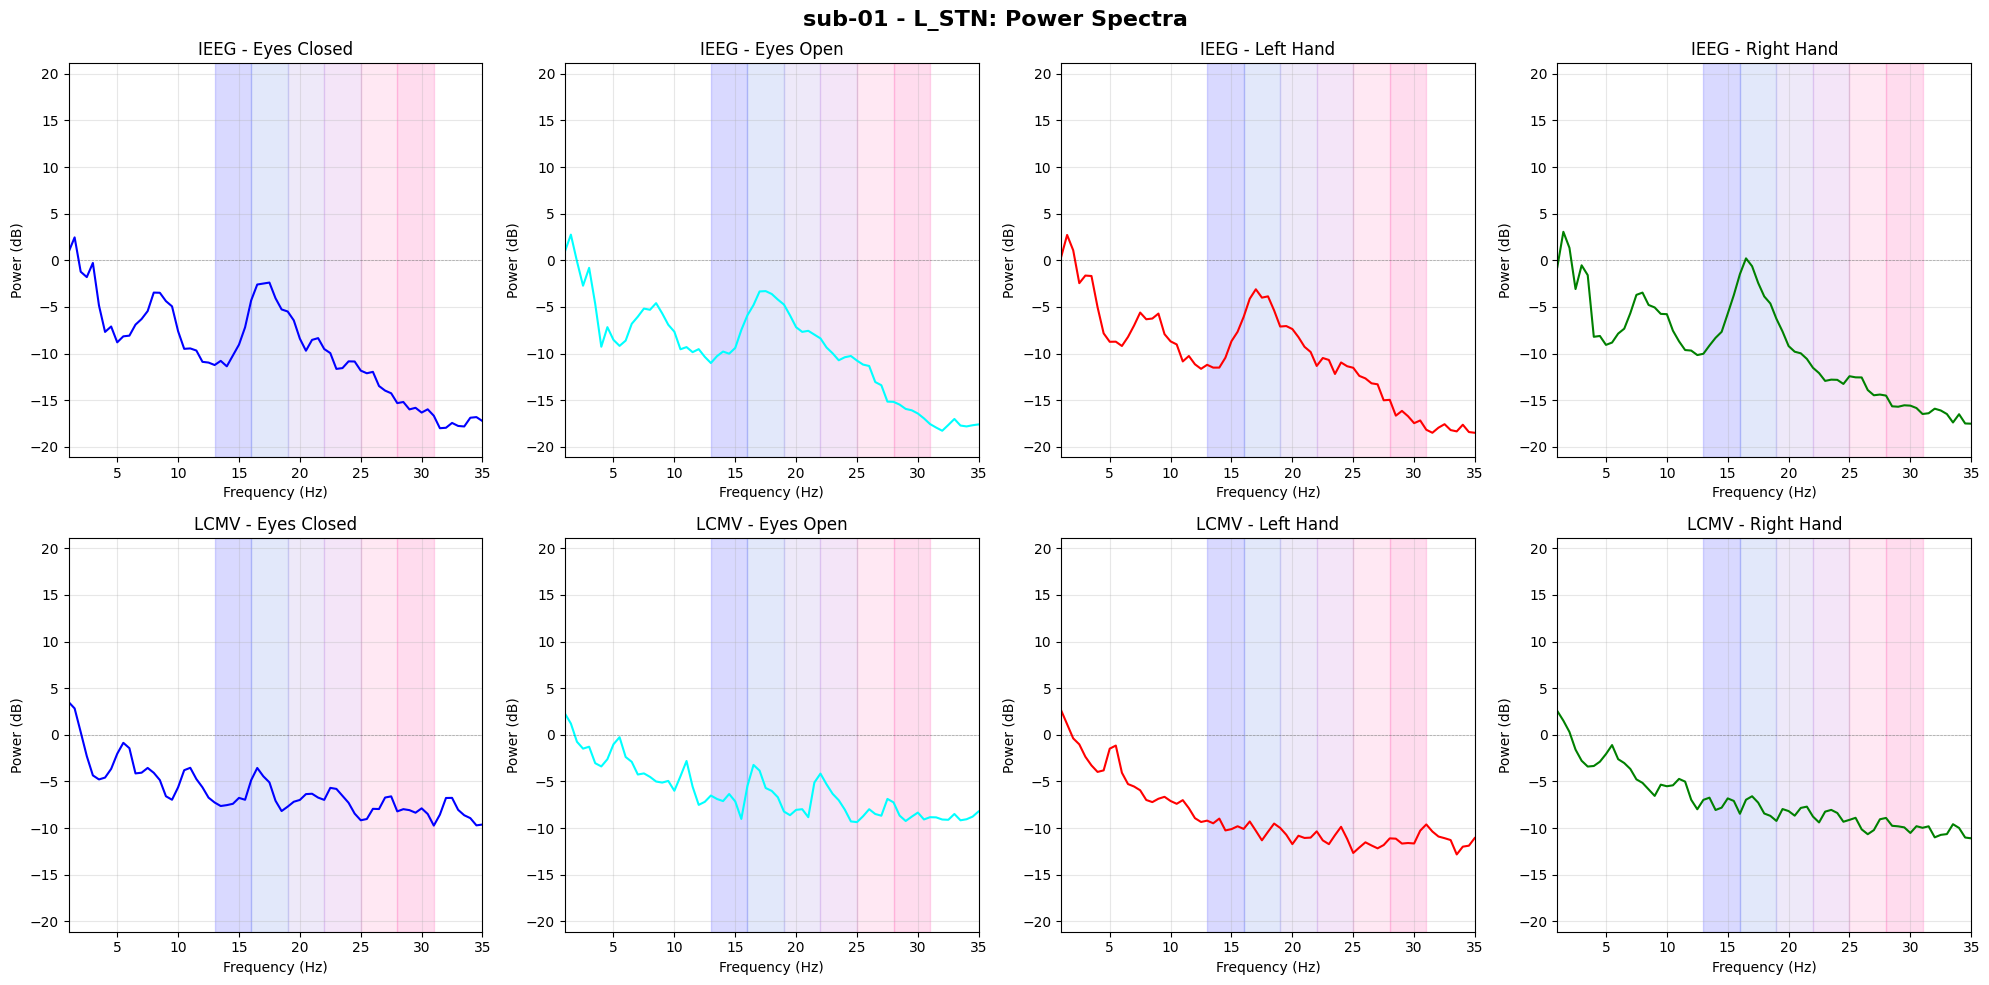

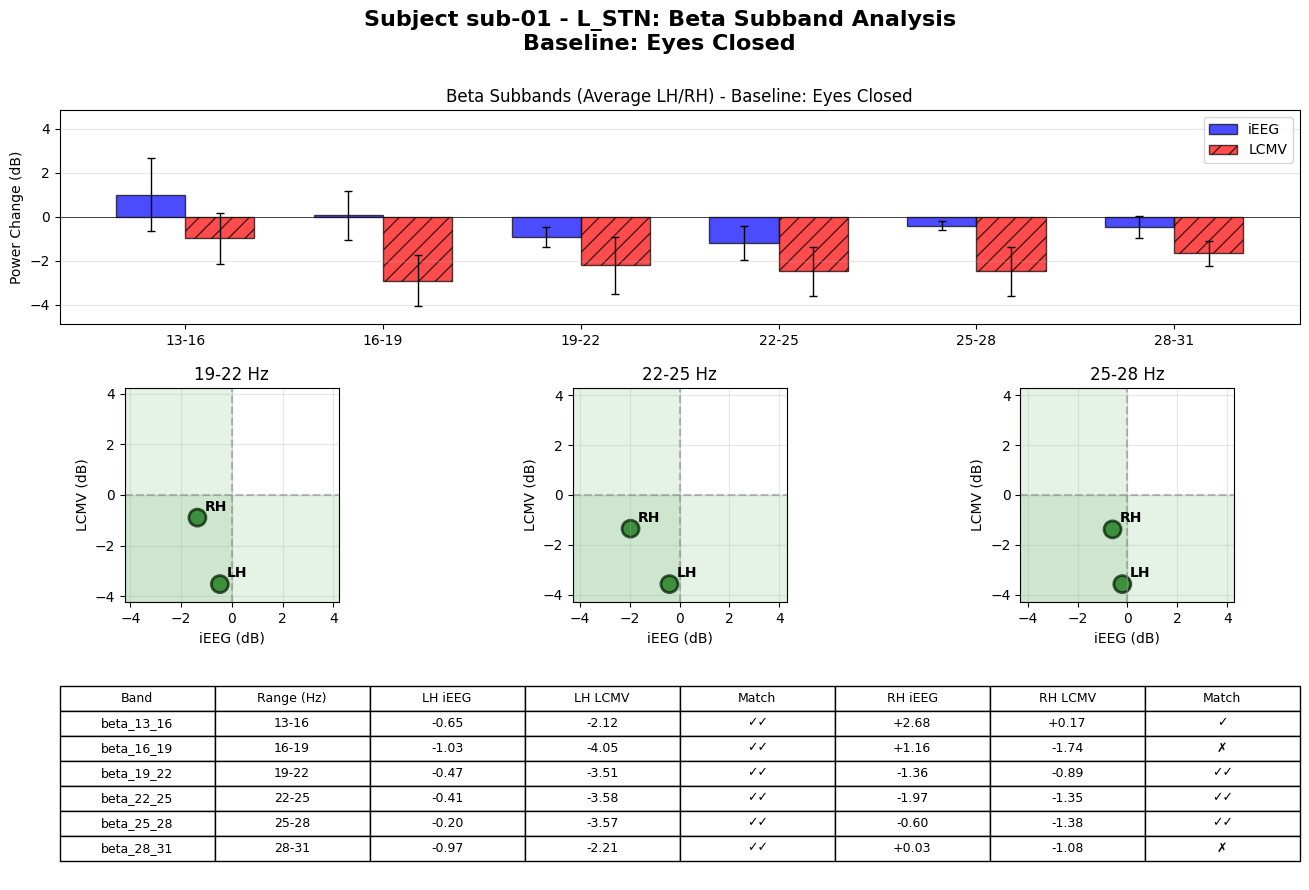

Plotting sub-01 - R_STN


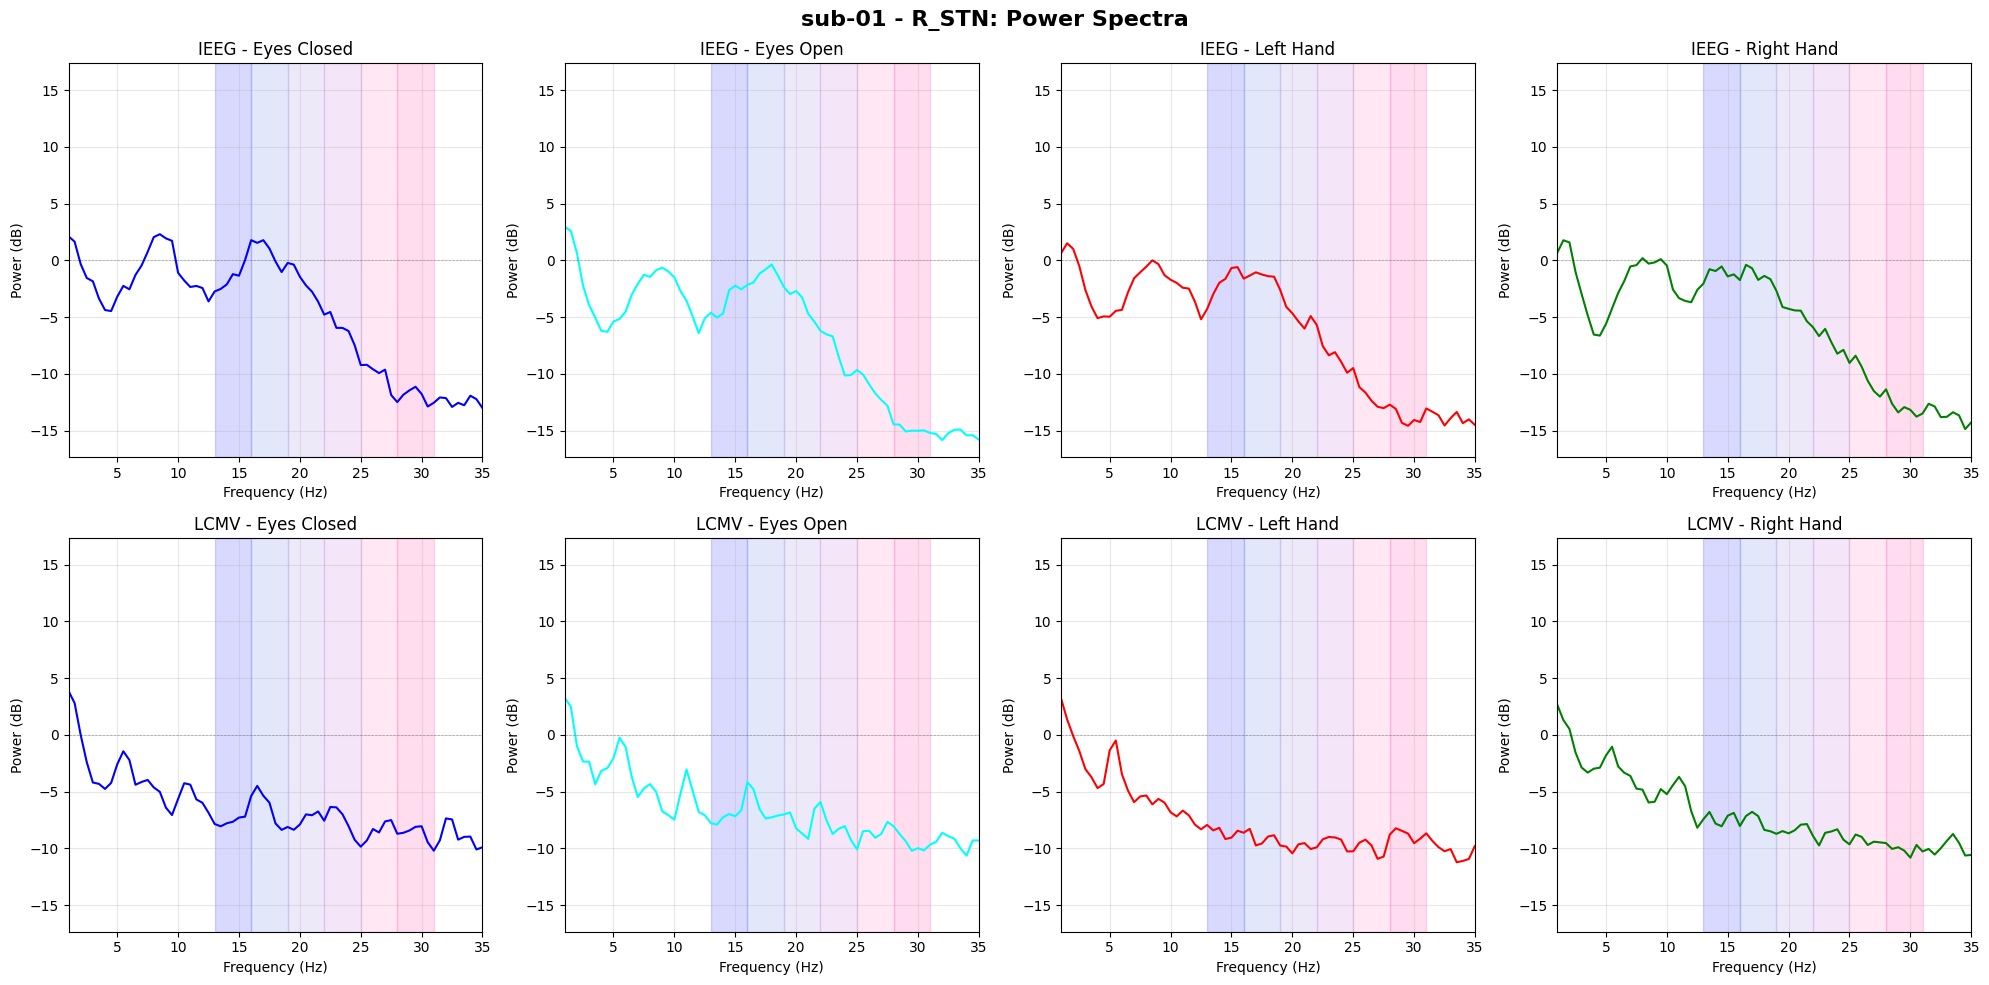

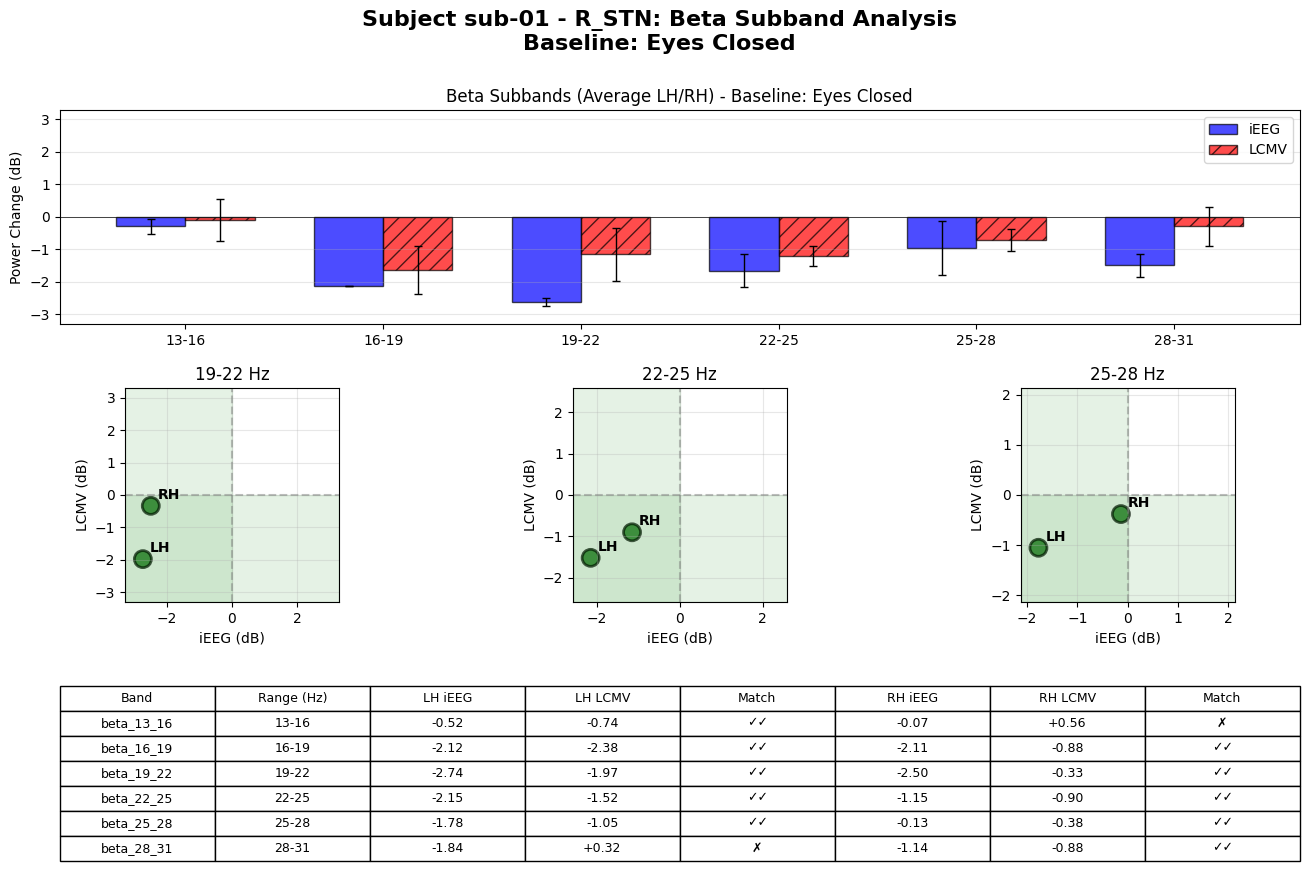

Plotting sub-05 - L_STN


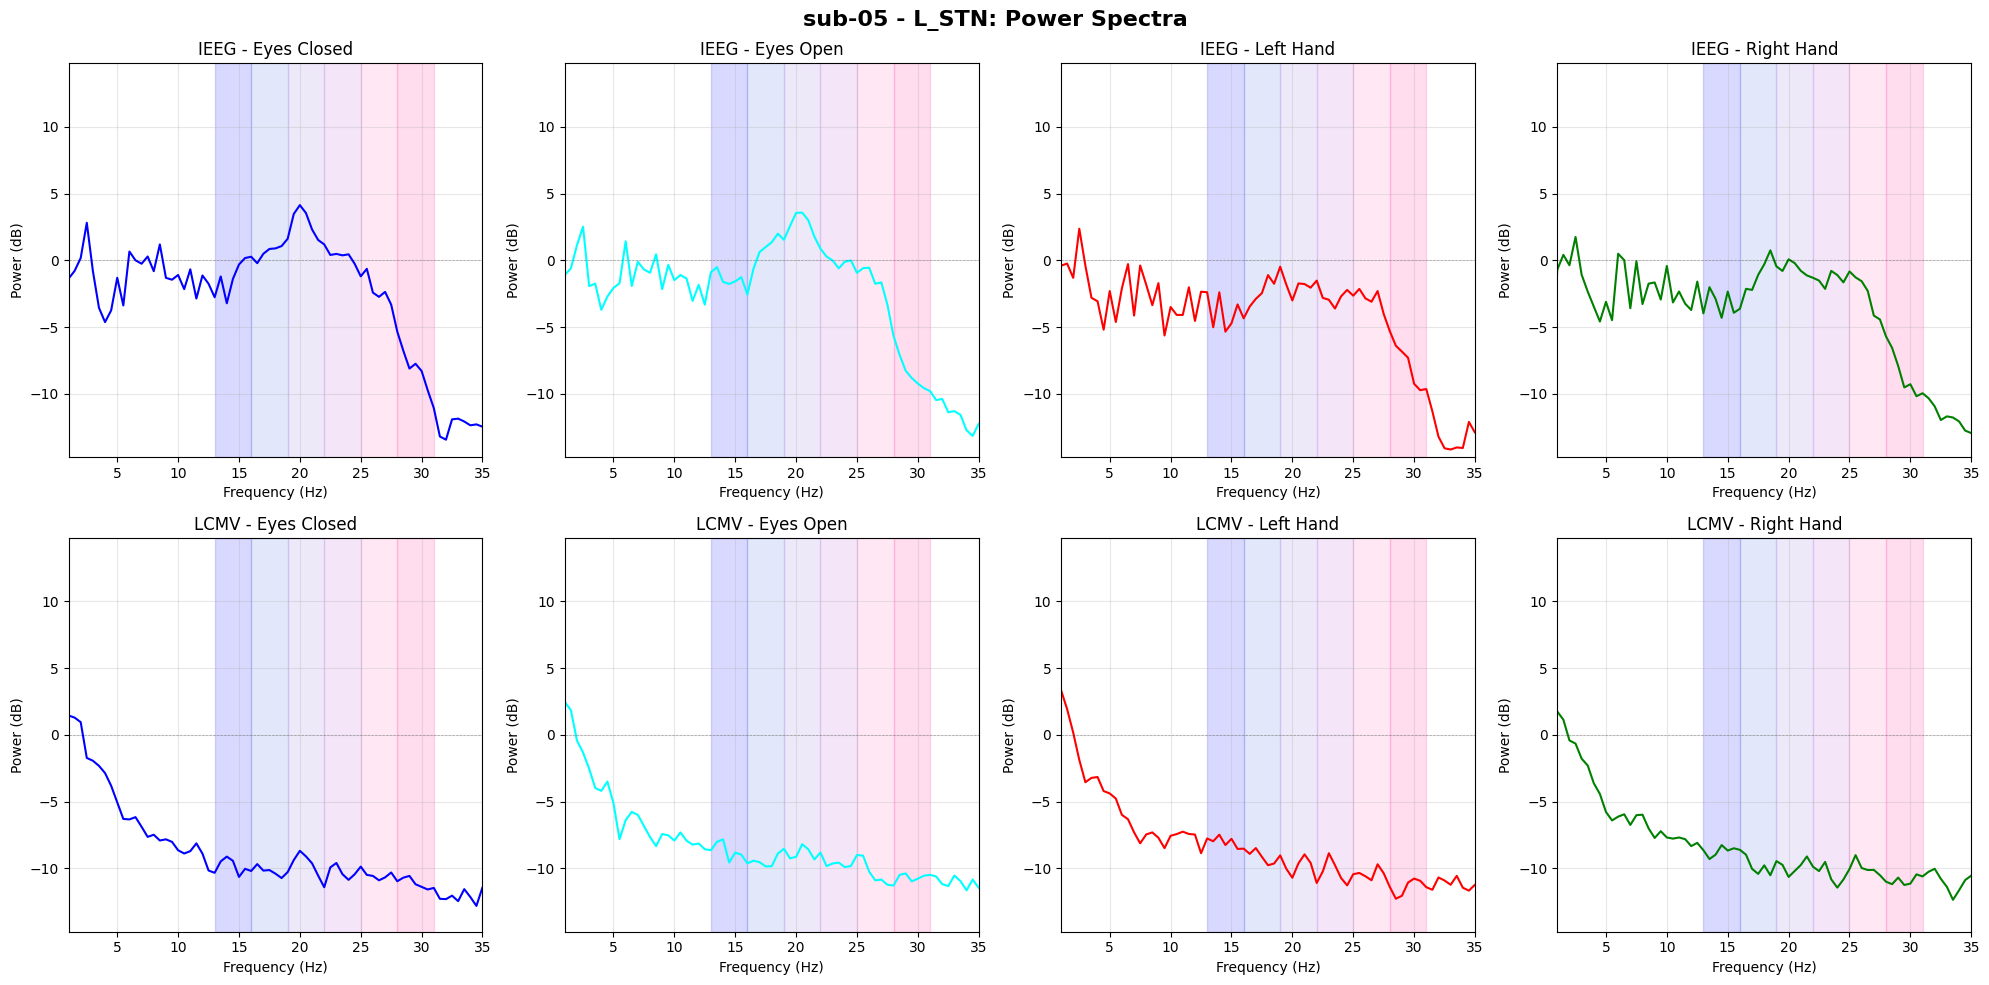

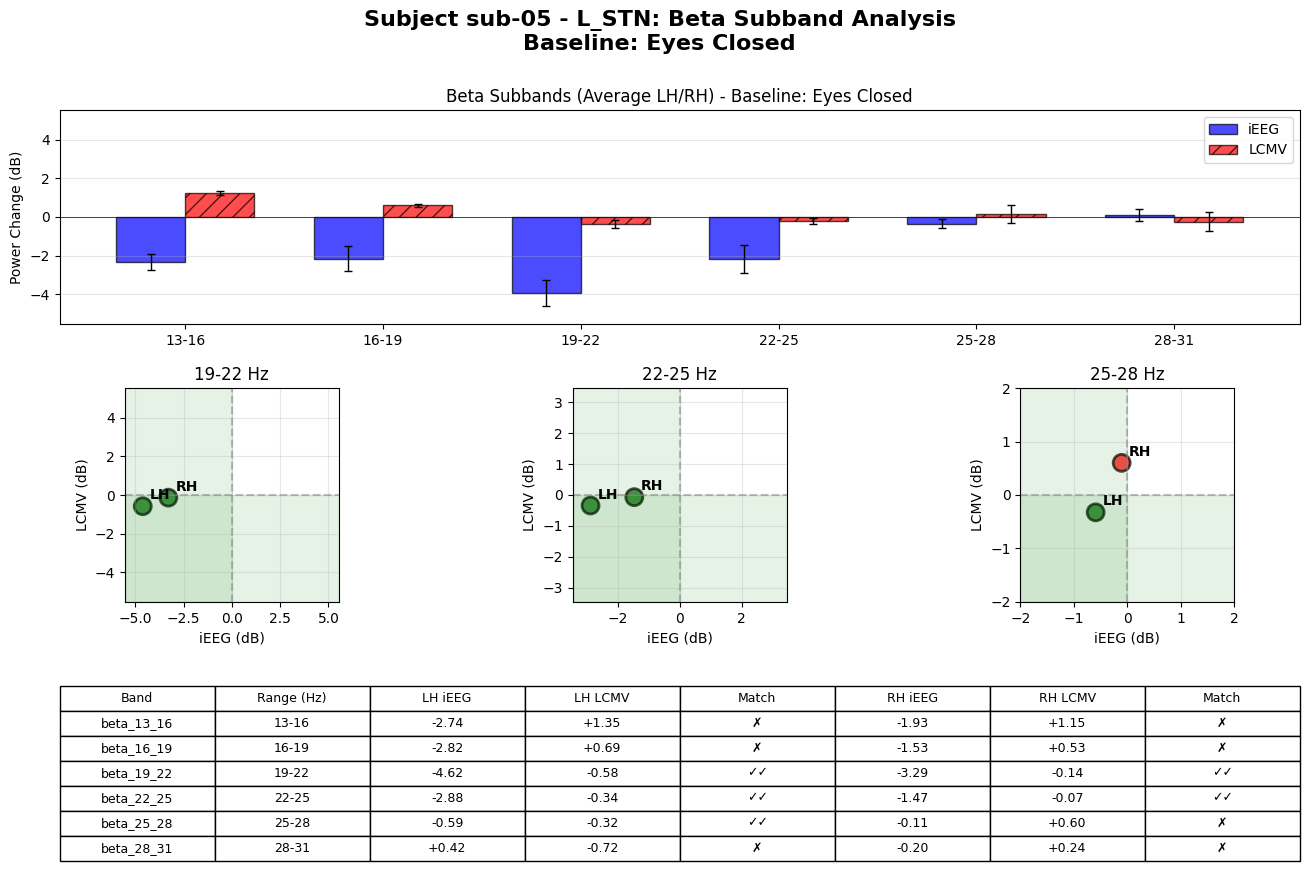

Plotting sub-05 - R_STN


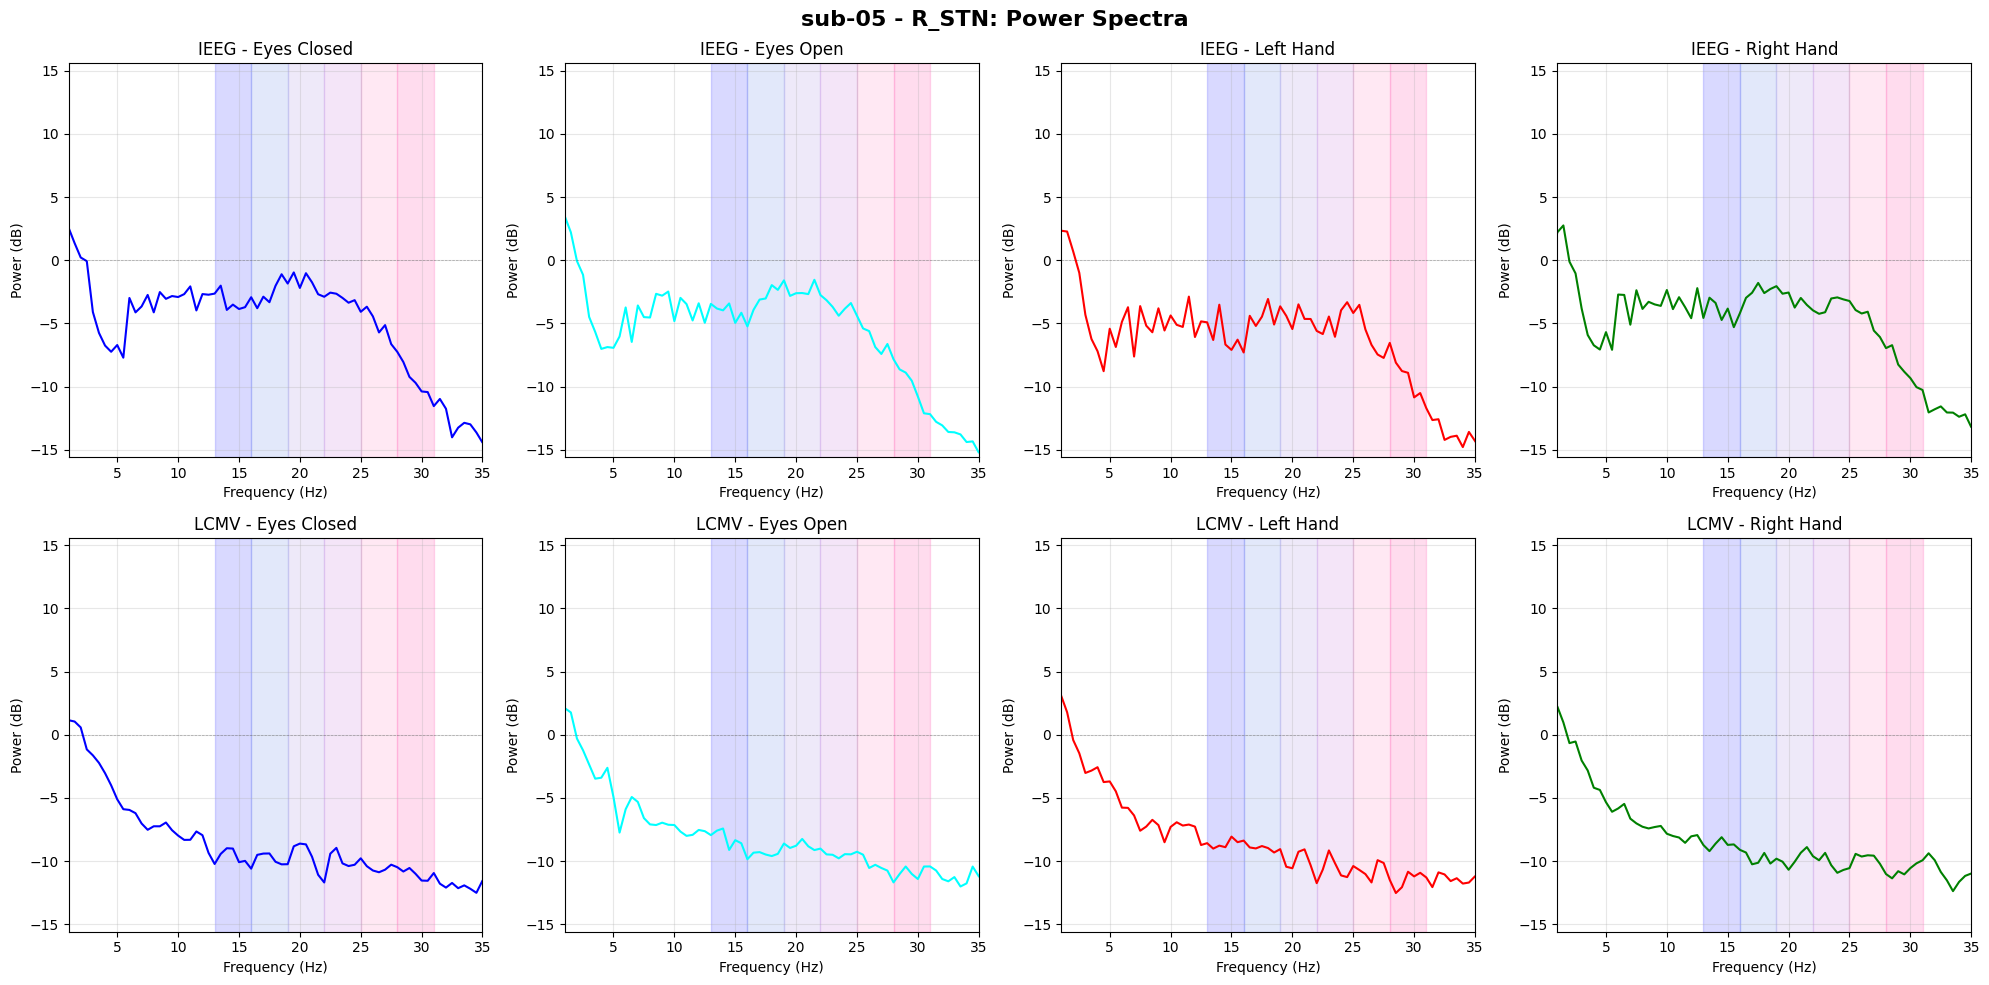

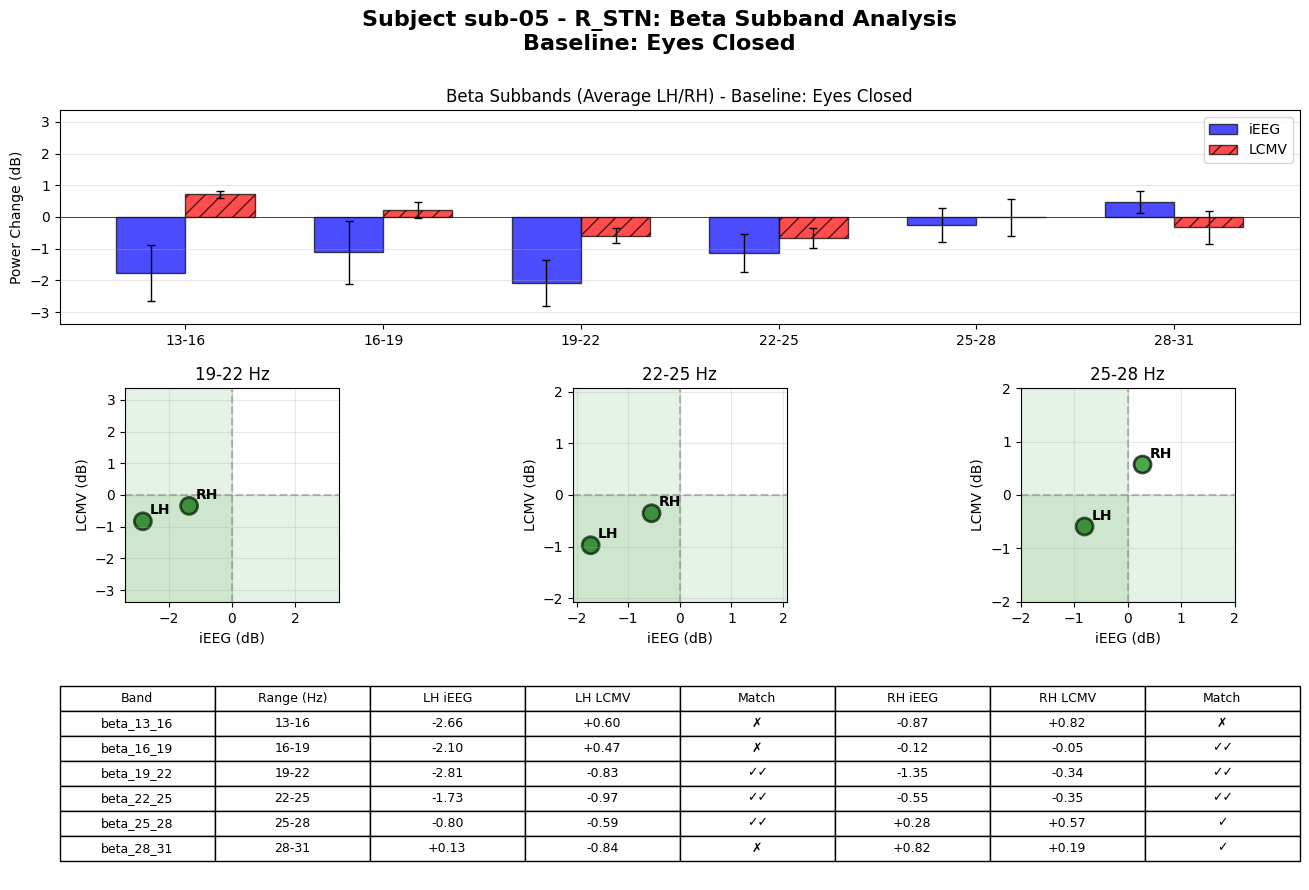

Plotting sub-07 - L_STN


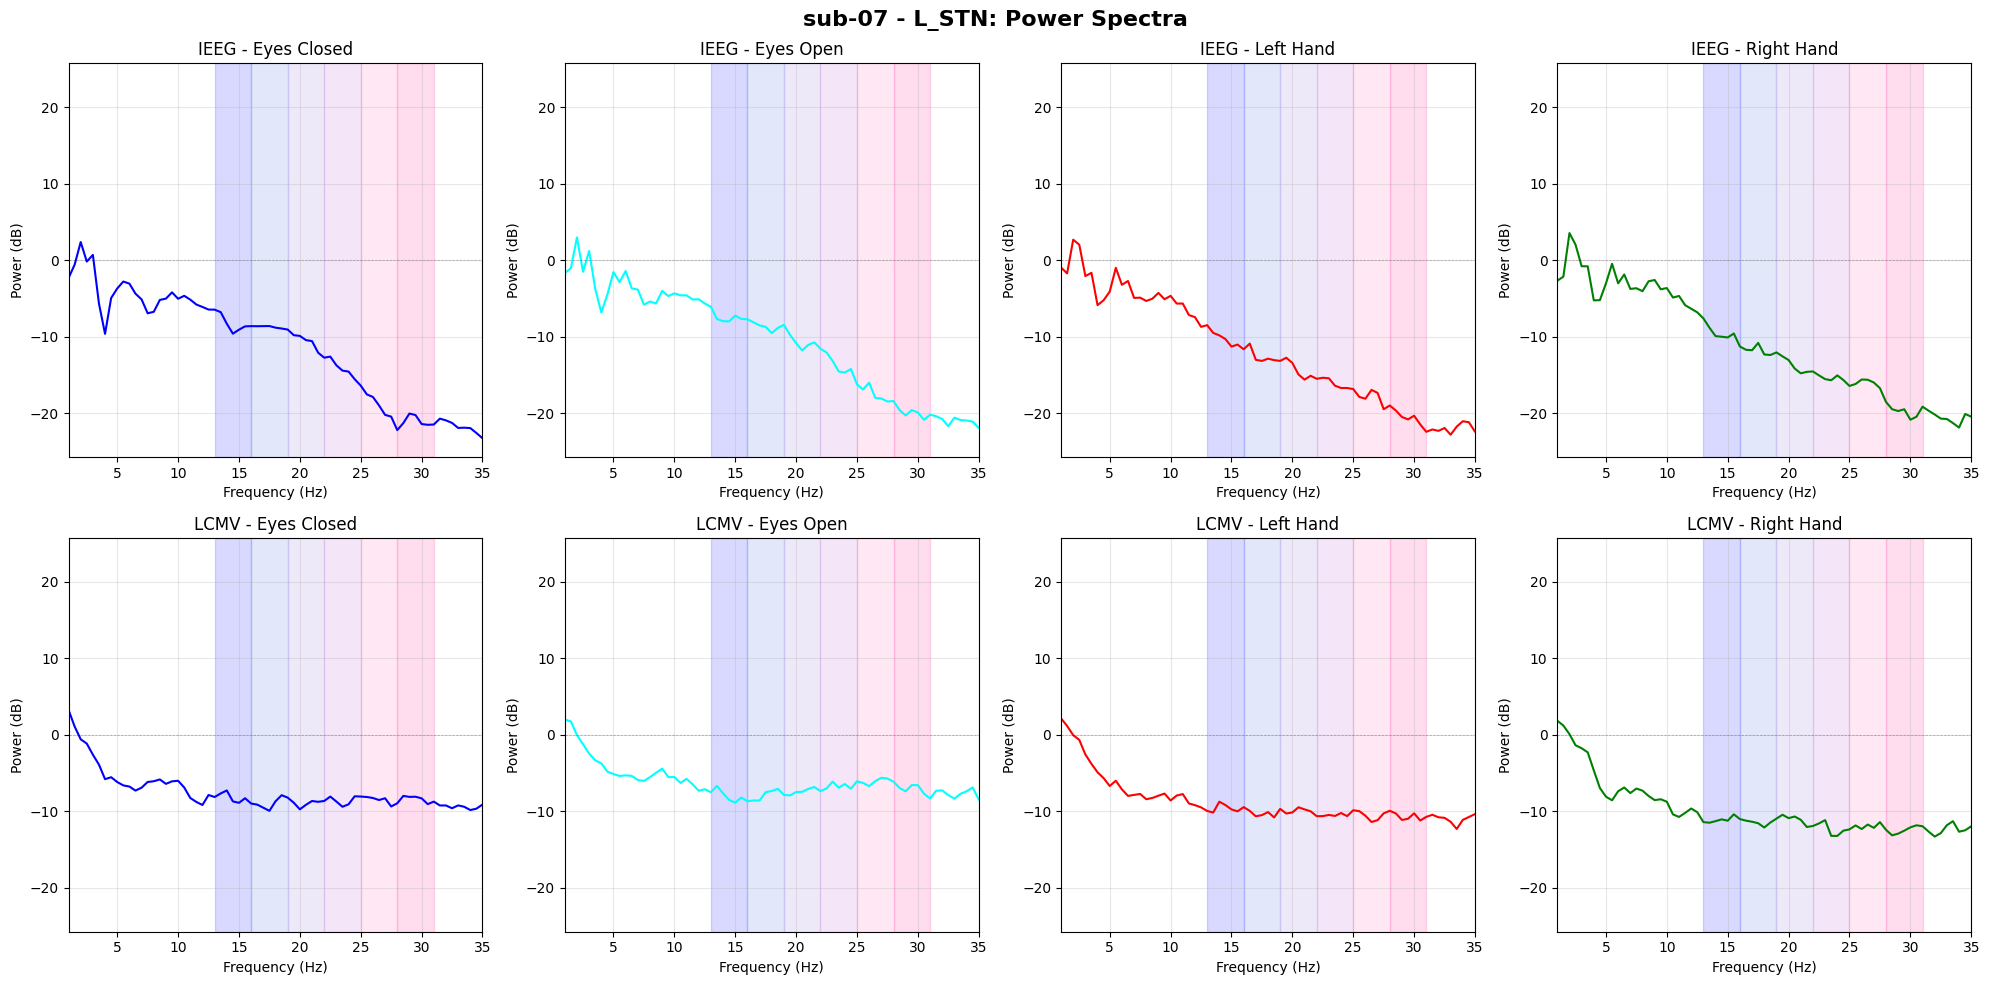

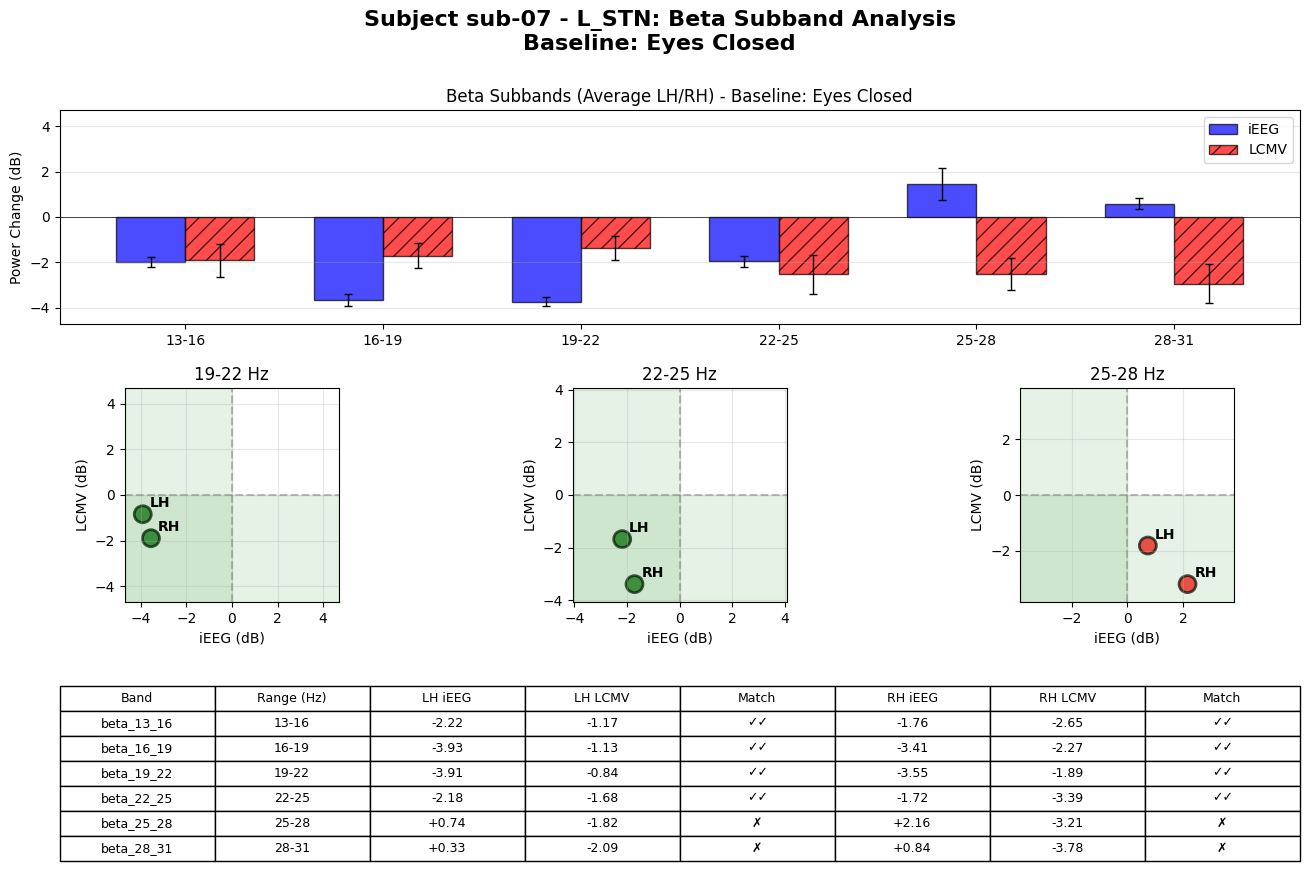

Plotting sub-10 - L_STN


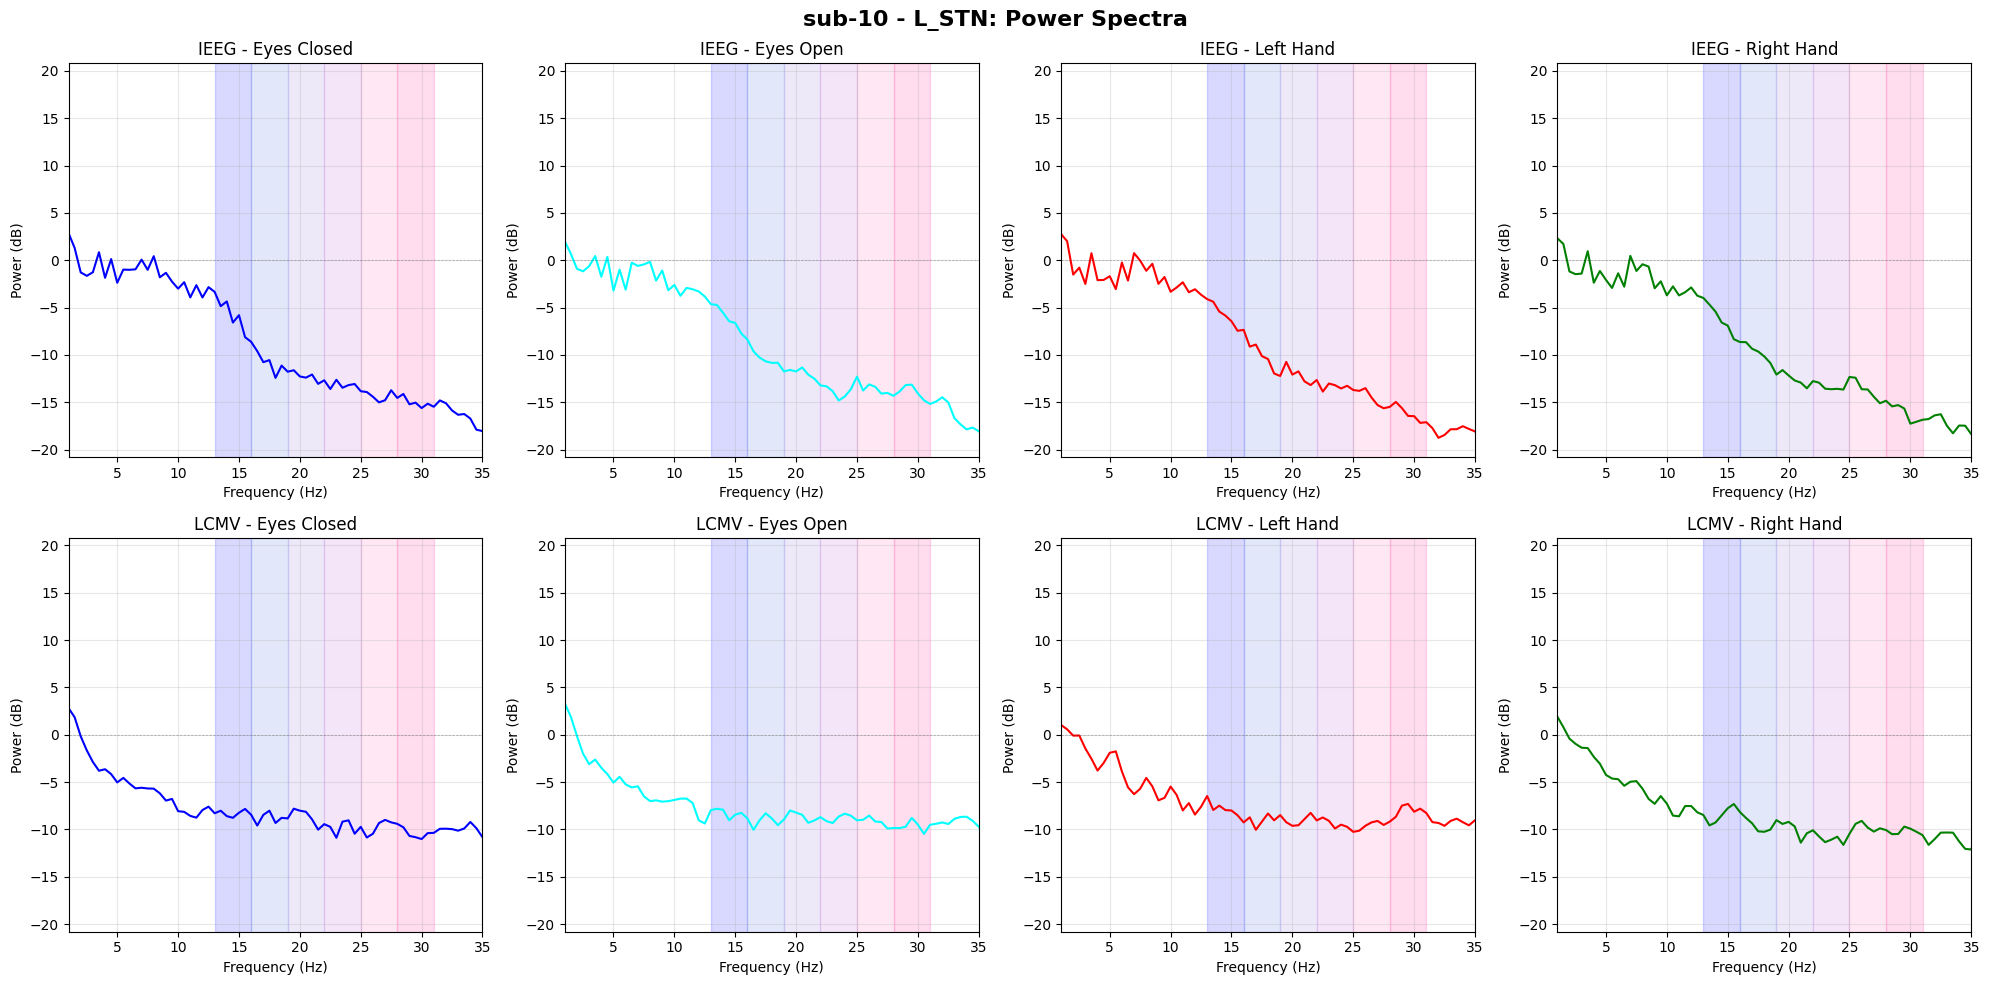

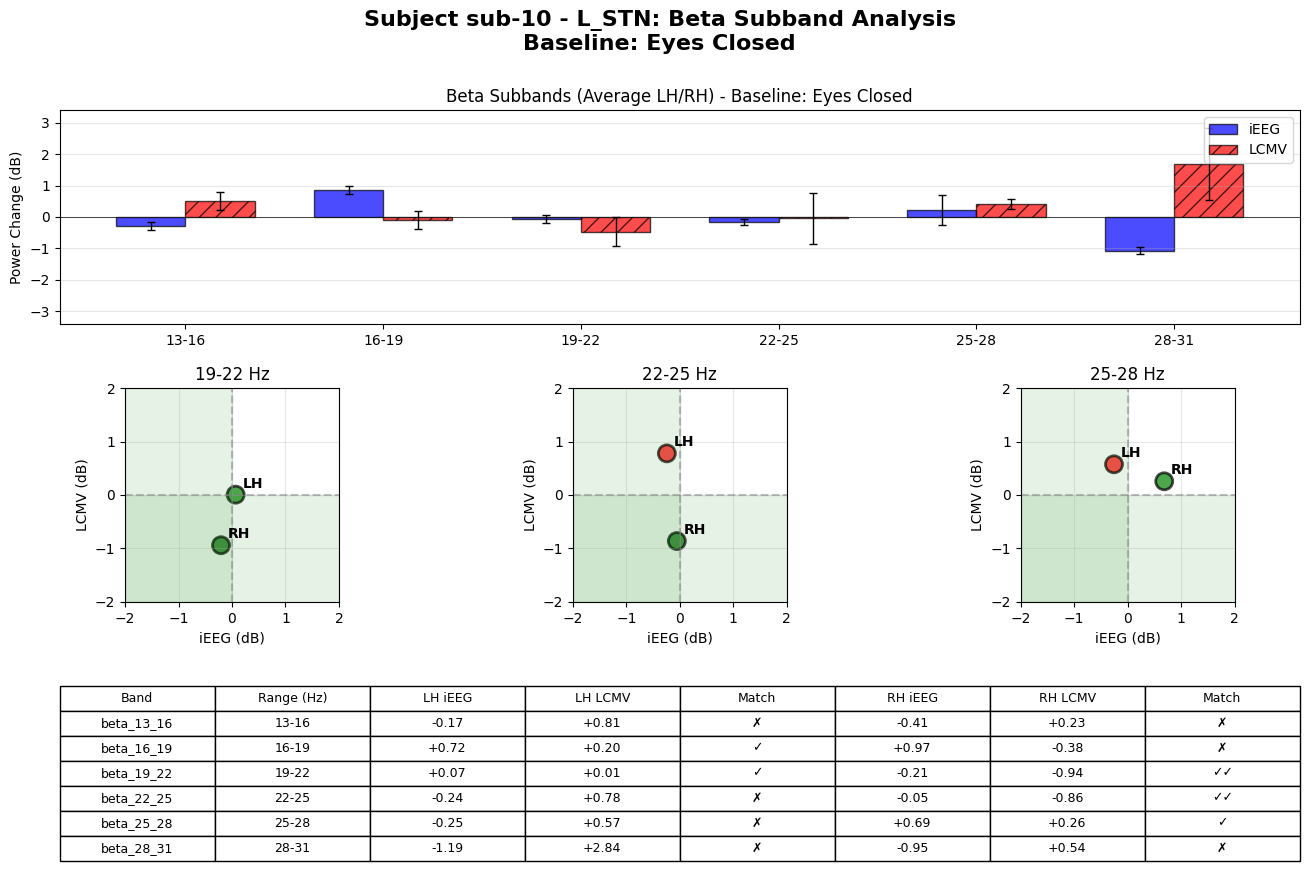

Plotting sub-10 - R_STN


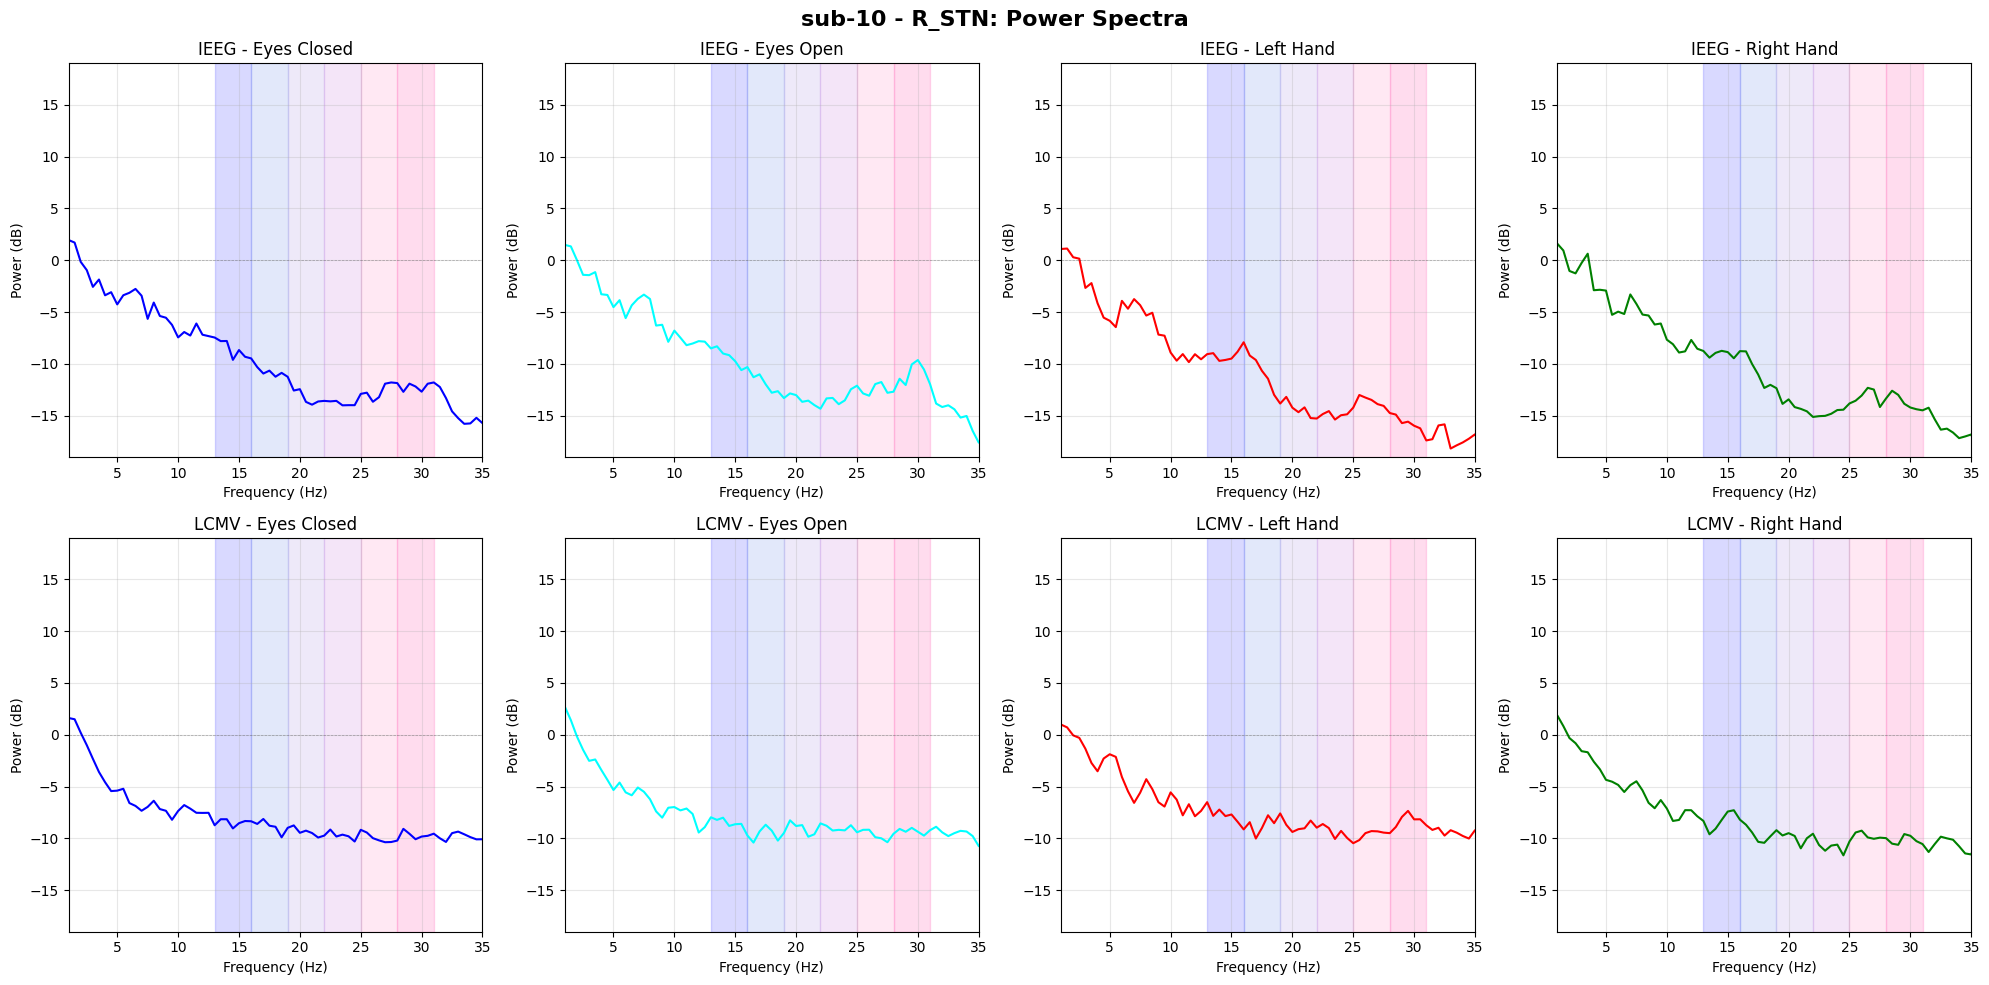

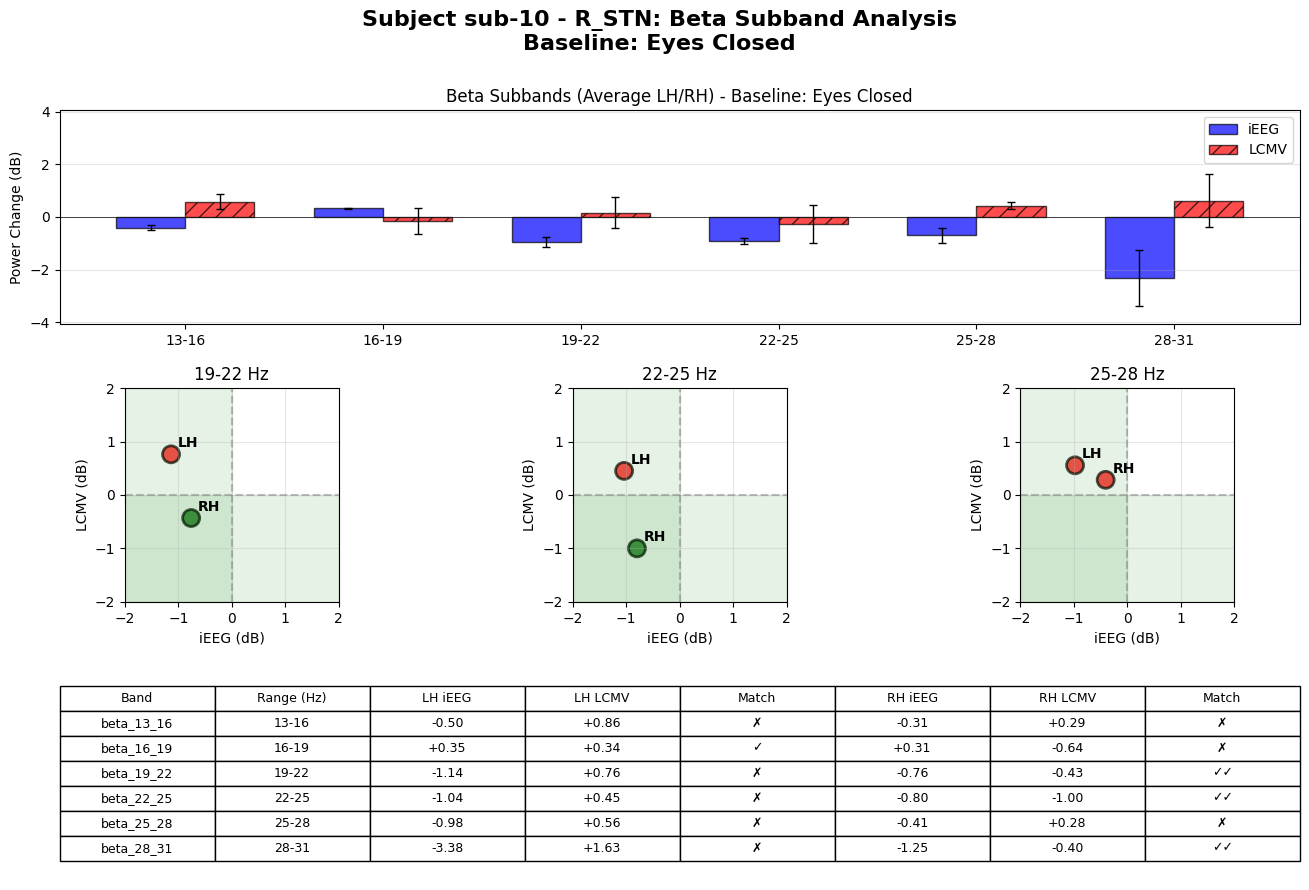

Plotting sub-12 - L_STN


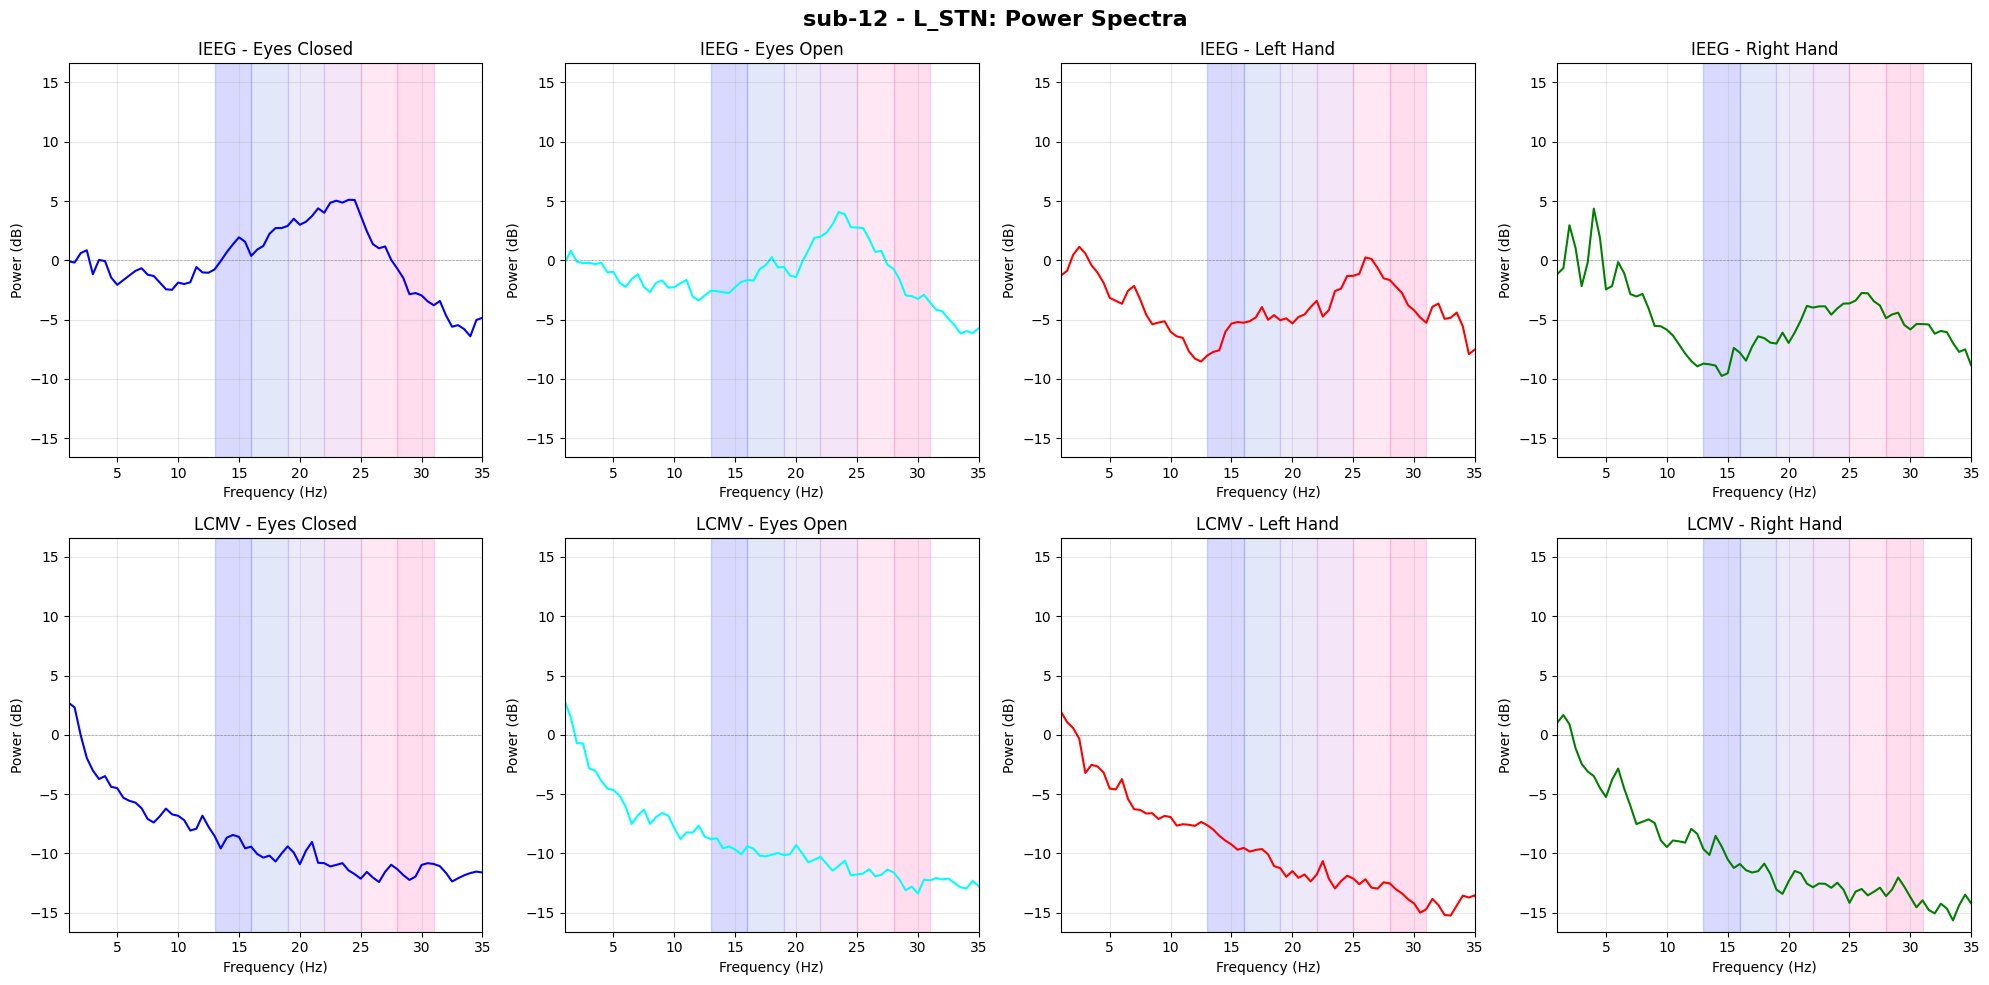

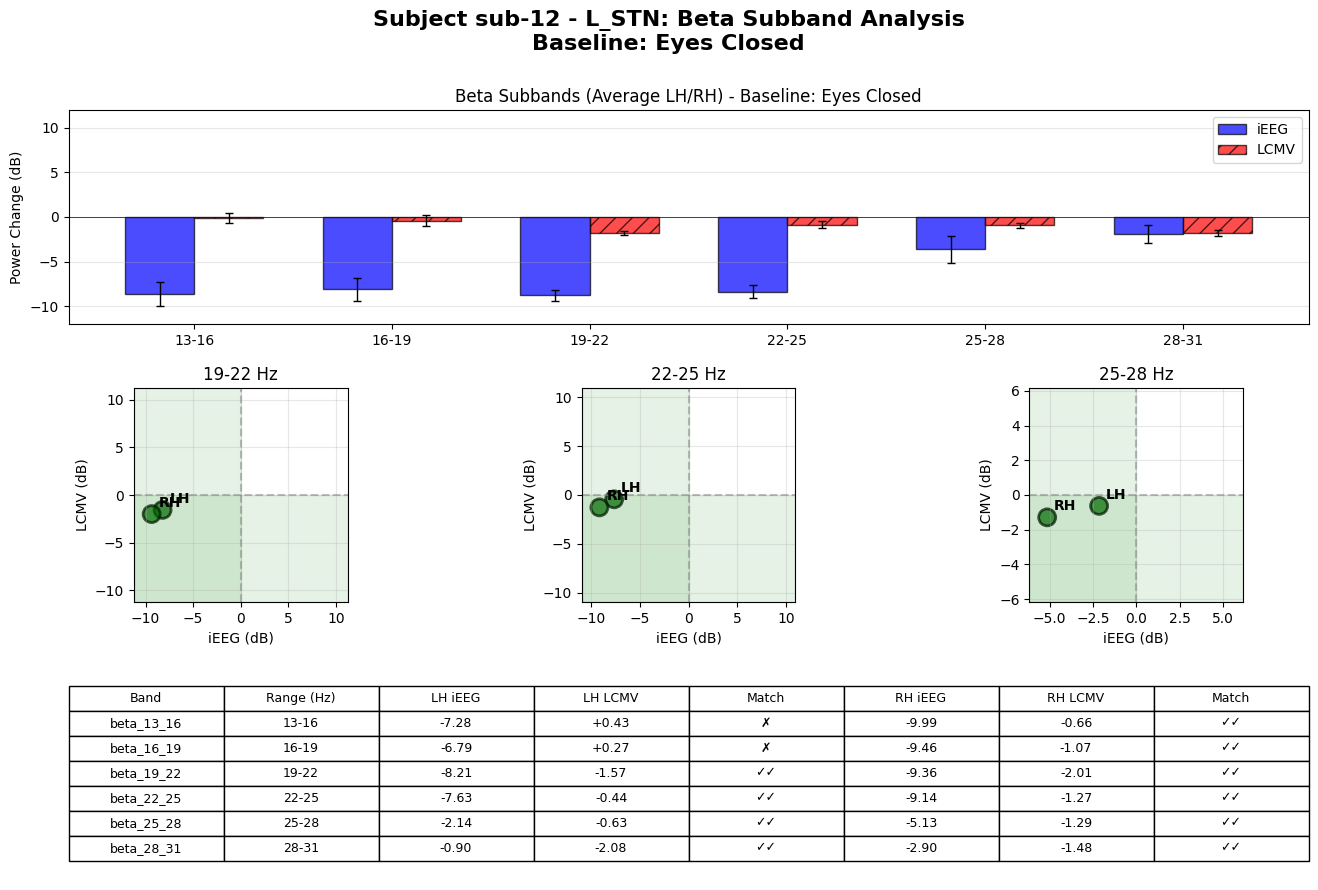

Plotting sub-12 - R_STN


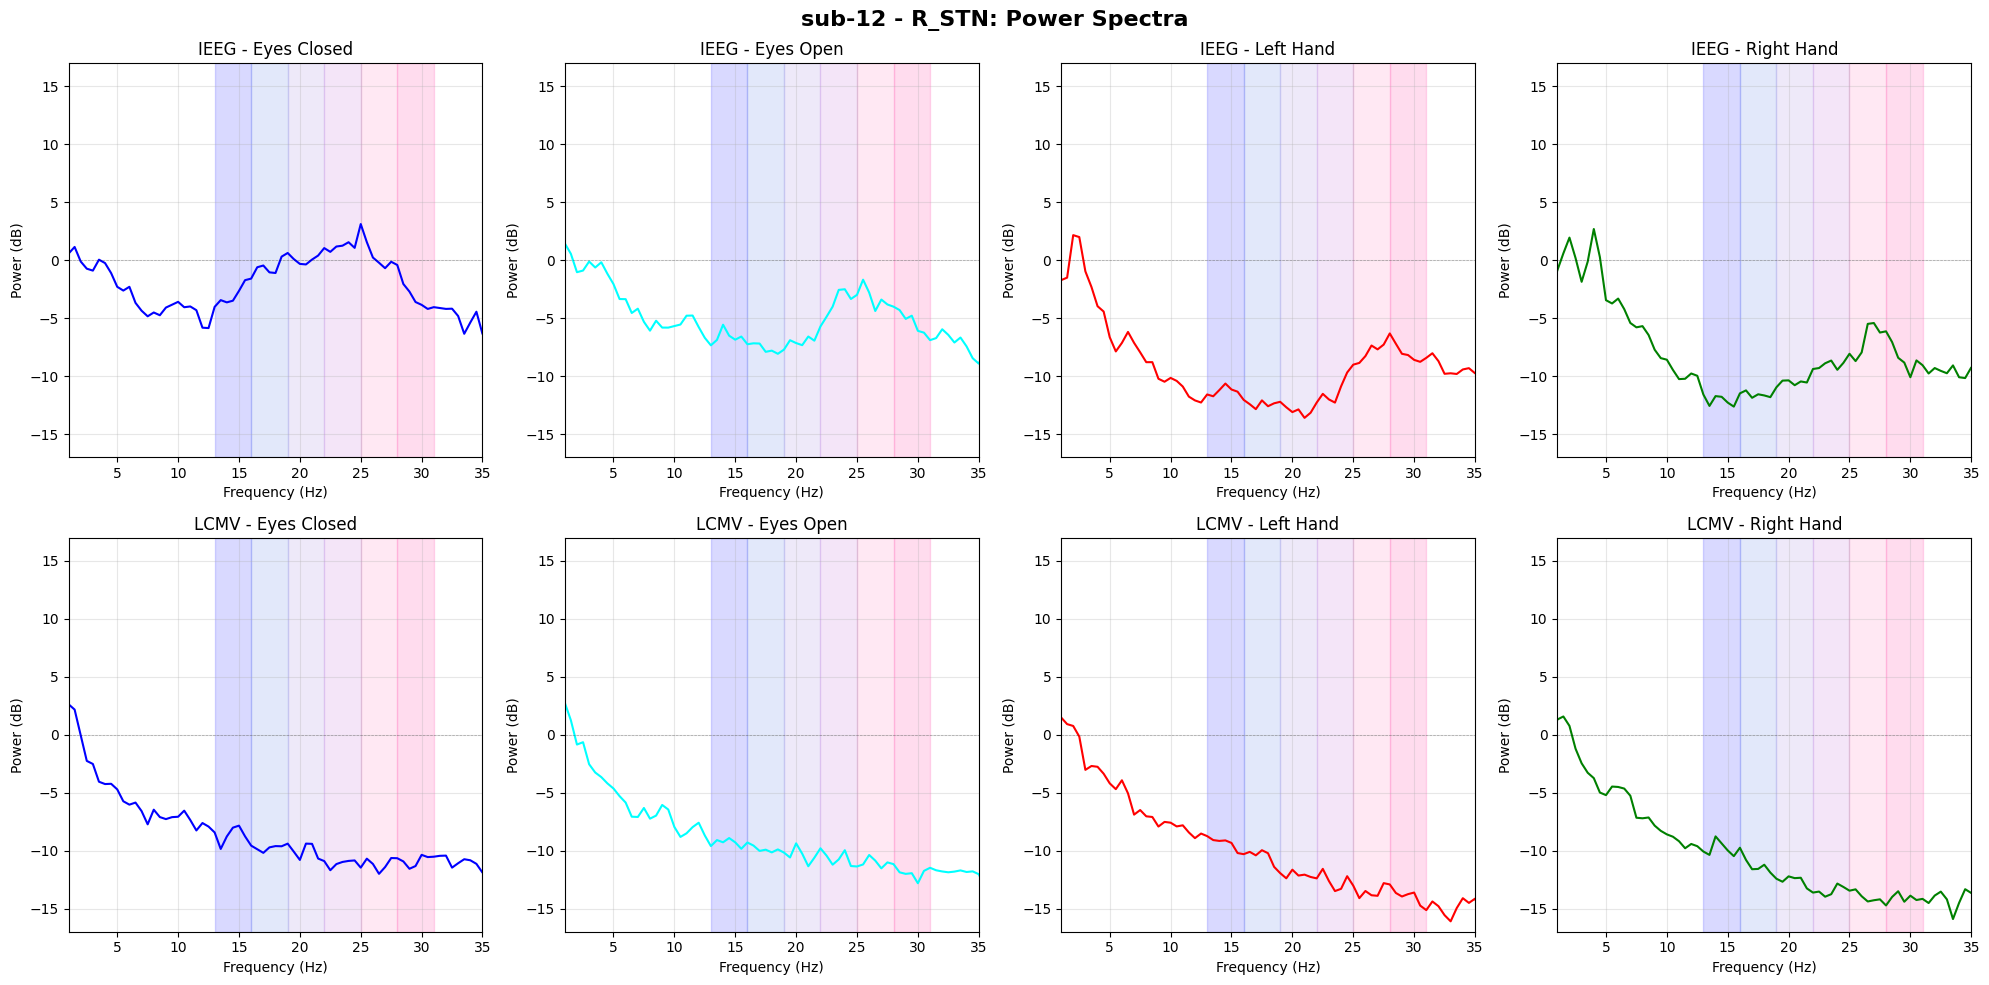

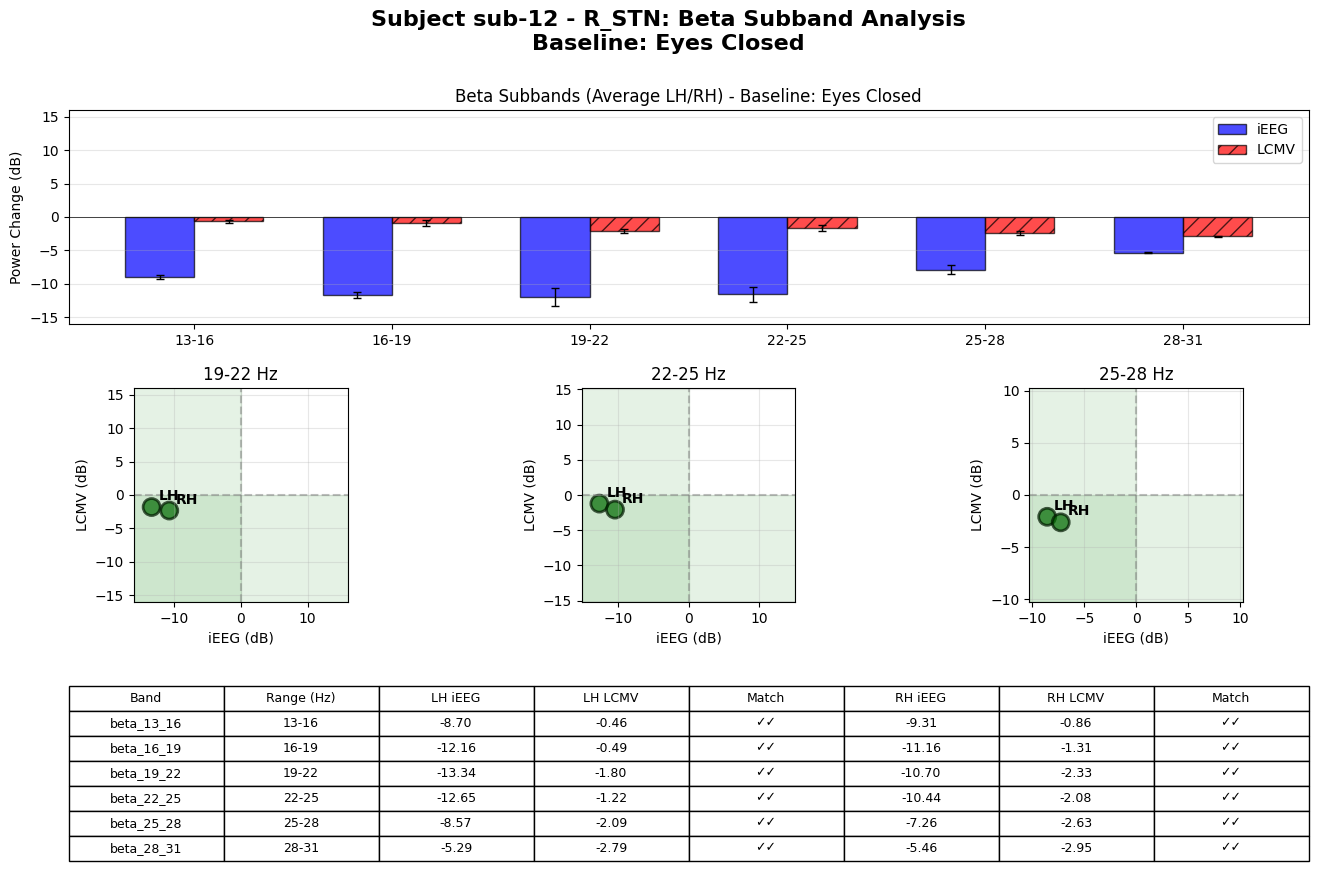

Plotting sub-14 - L_STN


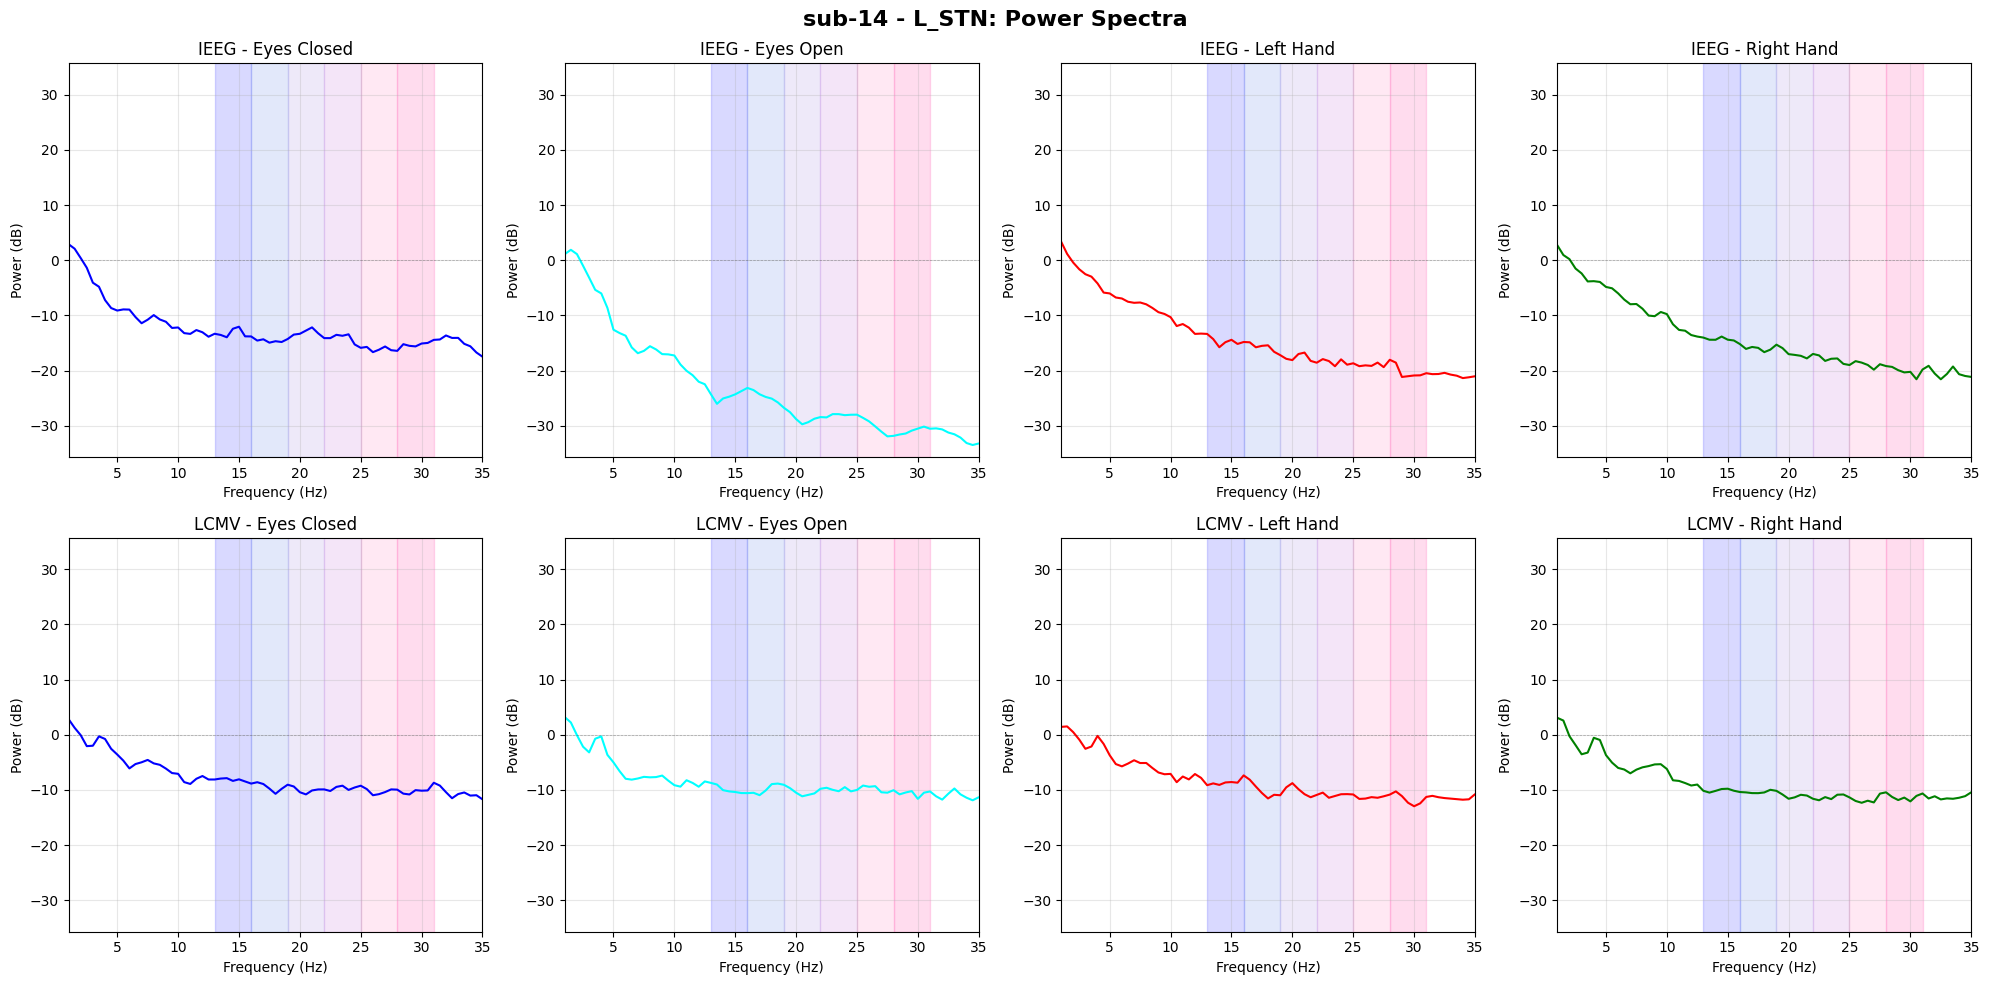

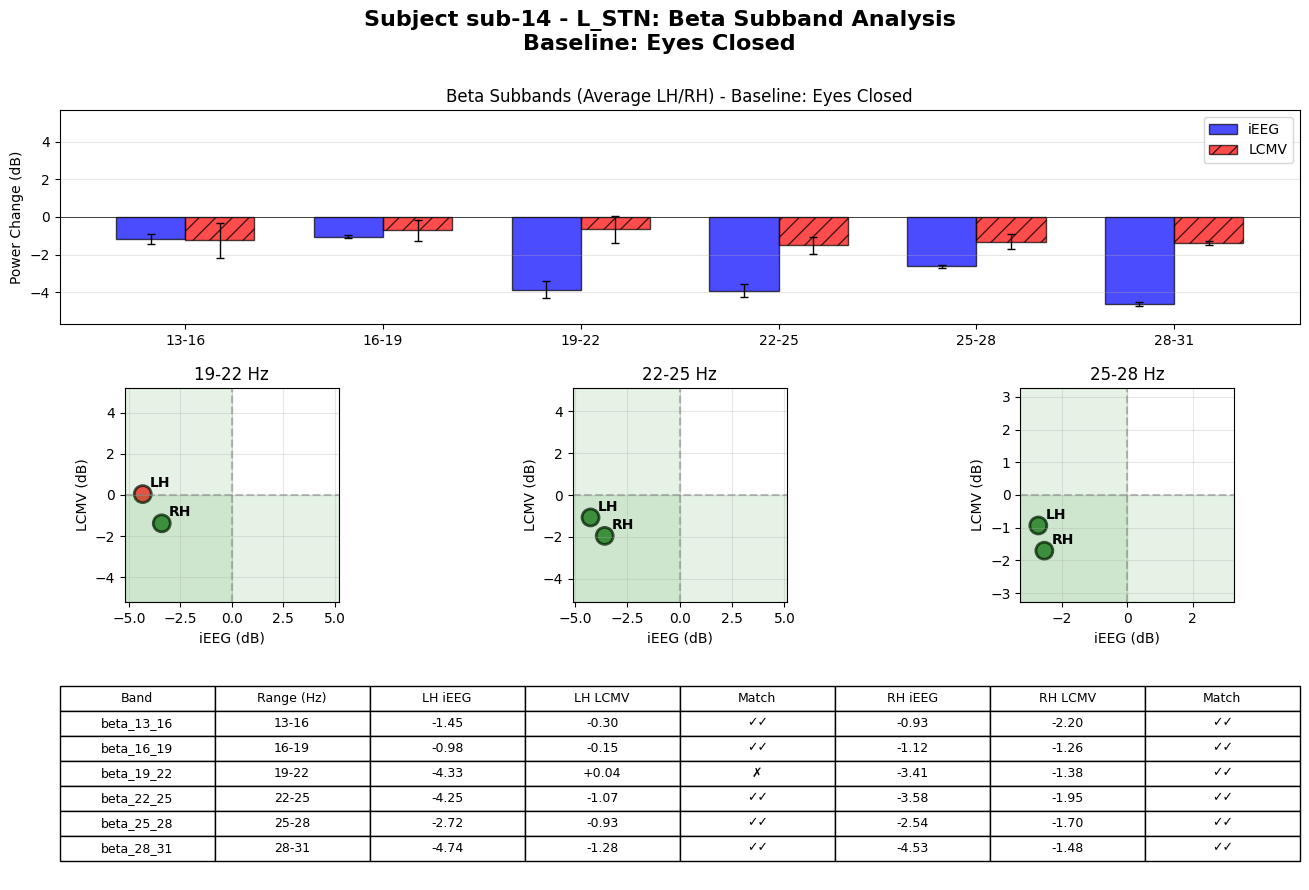

Plotting sub-14 - R_STN


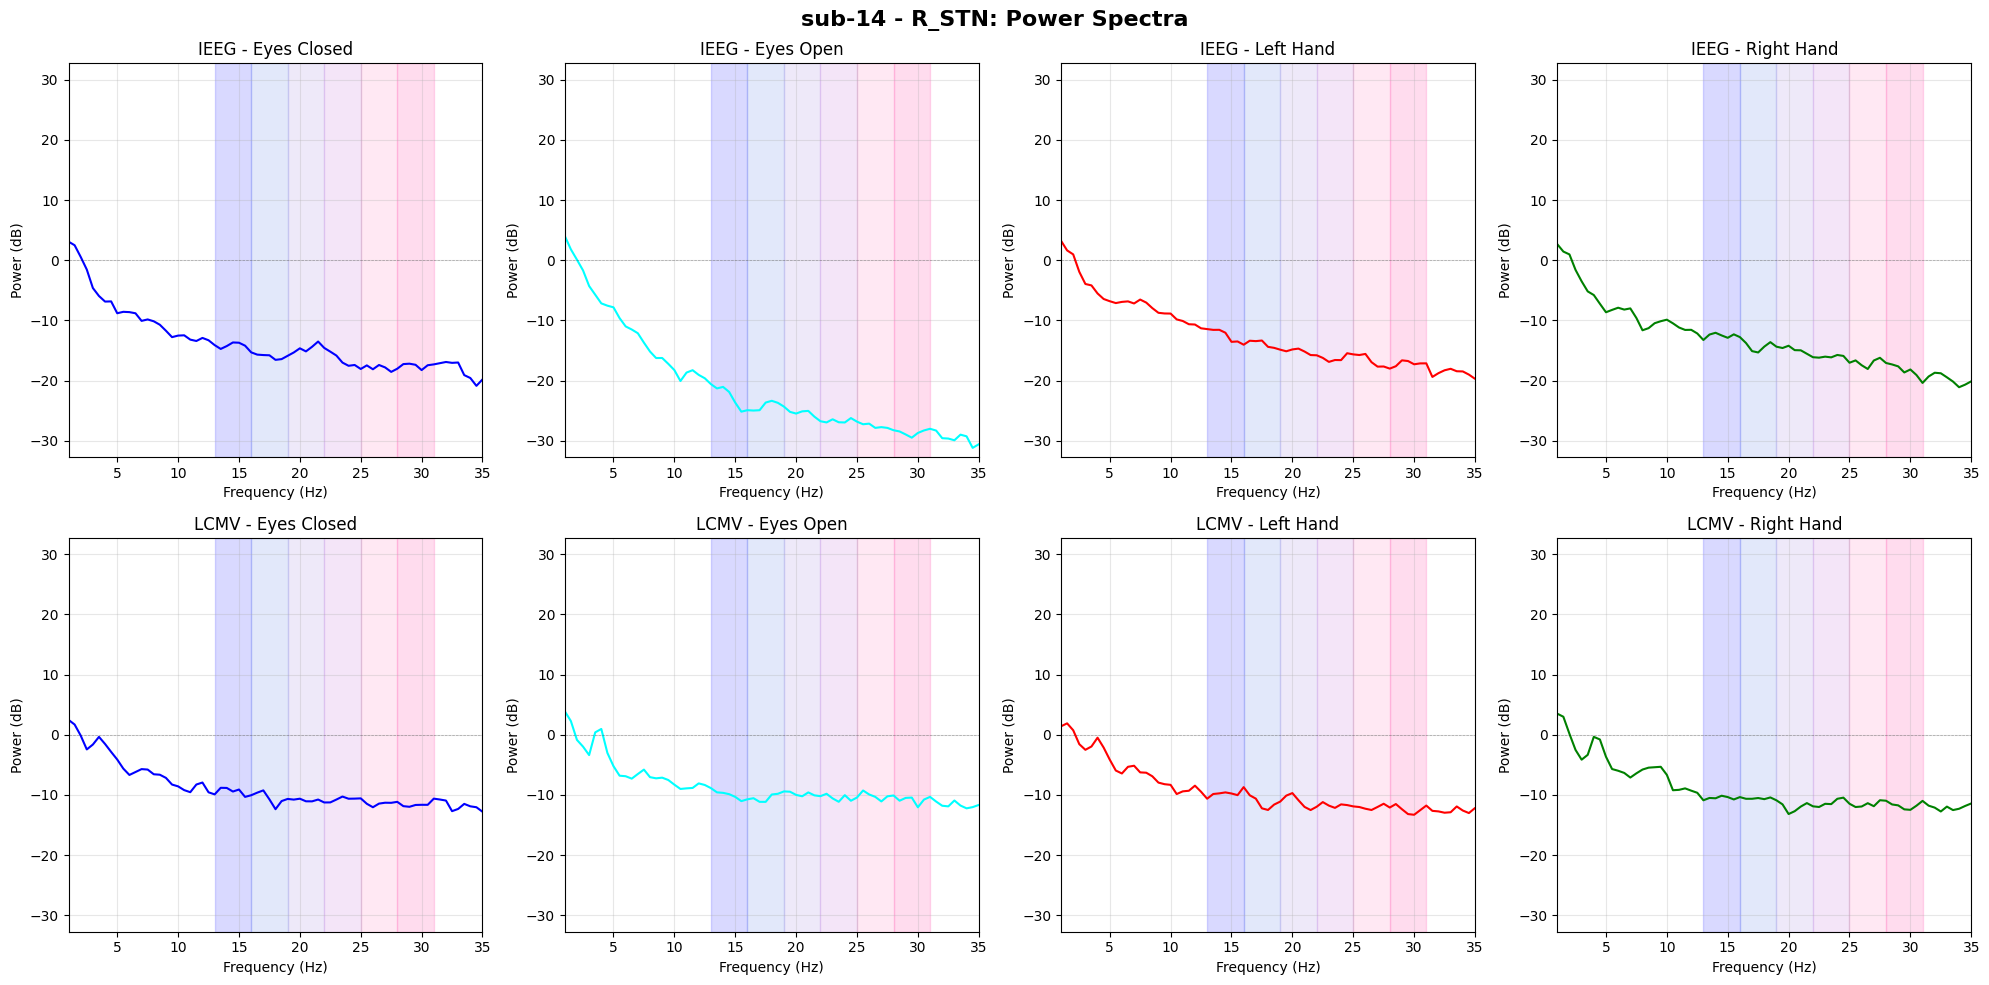

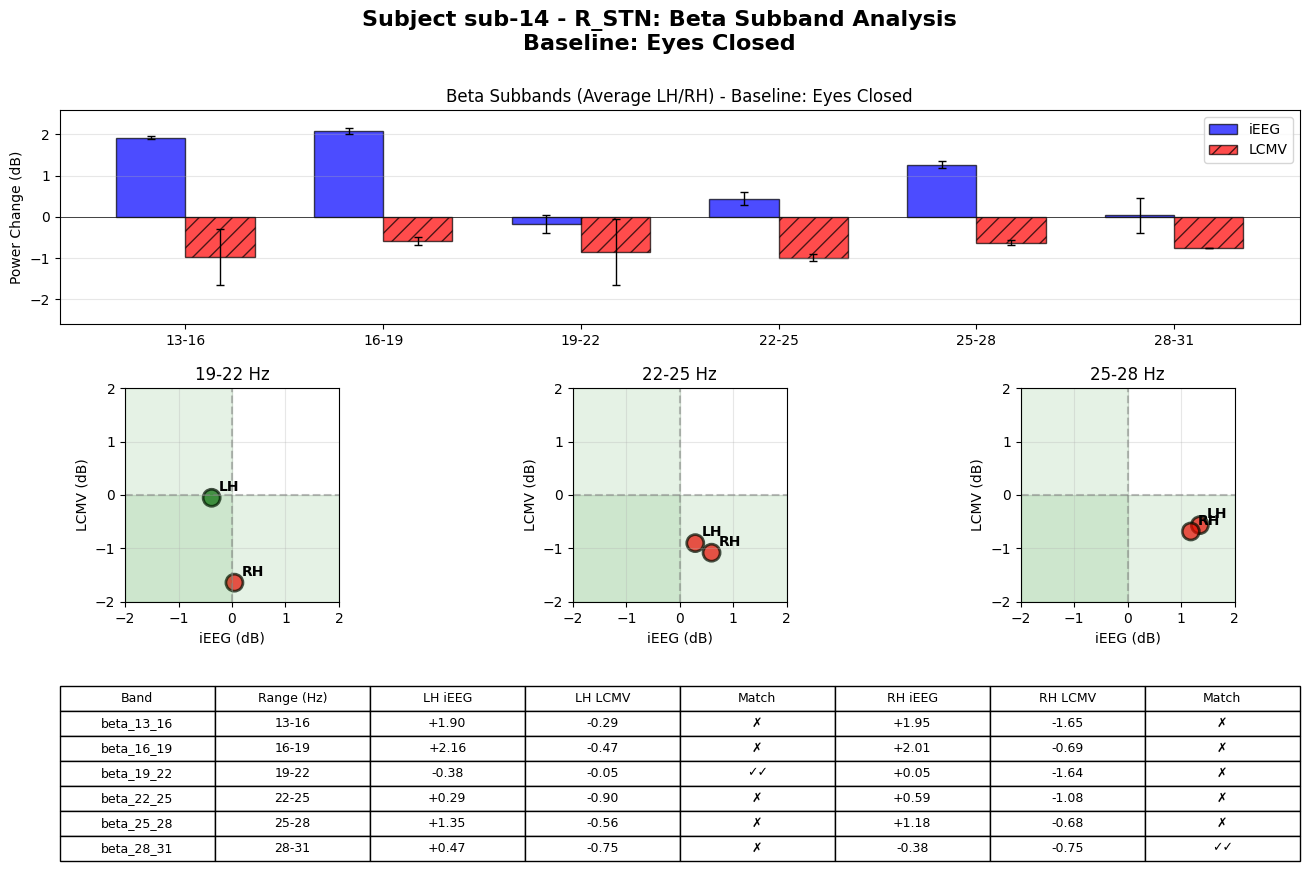

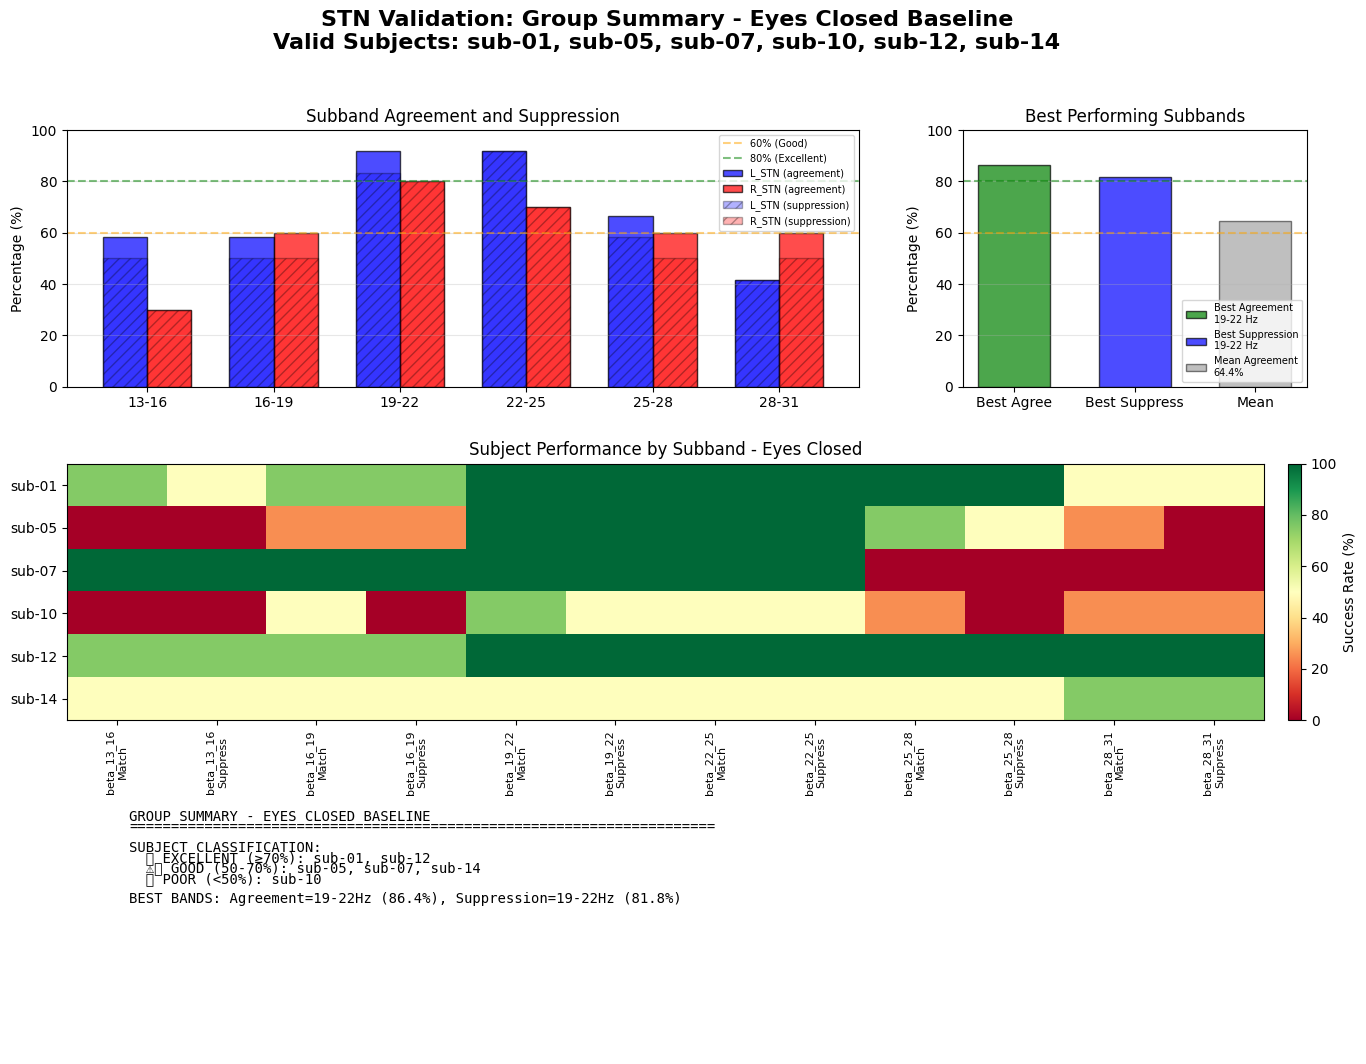

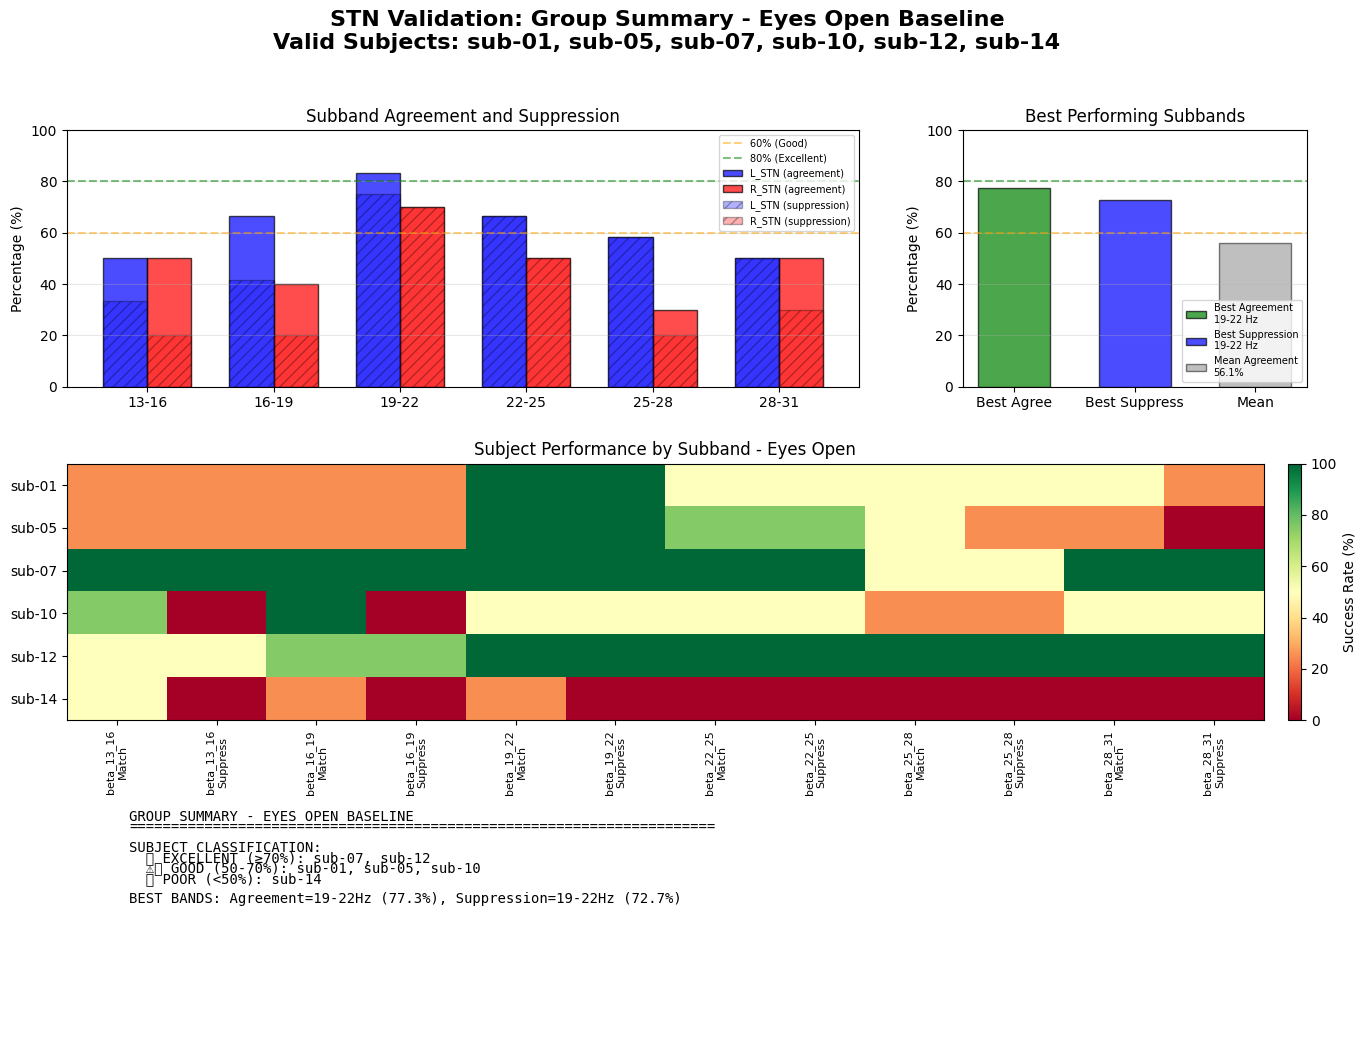


STEP 5: GENERATING REPORT
📊 HTML report saved to /mnt/movement/users/jaizor/xtra/derivatives/integrated/professional_report/validation_report_voxel.html

✅ ANALYSIS COMPLETE
Subjects analyzed: 6
Analysis type: voxel
Output directory: /mnt/movement/users/jaizor/xtra/derivatives/integrated/professional_report
HTML report: /mnt/movement/users/jaizor/xtra/derivatives/integrated/professional_report/validation_report_voxel.html


In [14]:
# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    IEEG_PATH = Path('/mnt/movement/users/jaizor/xtra/derivatives/integrated/consolidated_ieeg.npz')
    LCMV_PATH = Path('/mnt/movement/users/jaizor/xtra/derivatives/integrated/consolidated_lcmv.npz')
    OUTPUT_DIR = Path('/mnt/movement/users/jaizor/xtra/derivatives/integrated/professional_report')
    
    # Run analysis
    results = run_analysis(
        ieeg_path=IEEG_PATH,
        lcmv_path=LCMV_PATH,
        output_dir=OUTPUT_DIR,
        analysis_type='voxel',  # or 'atlas'
        make_plots=True,
        save_plots=False
    )